# Greek-Neutral Hedging: A Unified Multi-Strategy Backtest

This notebook implements and compares five hedging strategies for a short options position
on a synthetic equity underlier. All strategies share a common base book, data pipeline,
and rebalancing framework so the comparison is like-for-like.

## Research question
Which Greek-neutral hedging strategy offers the best trade-off between residual risk reduction,
hedge coverage, and implementation cost across market regimes?

## Strategies compared
1. **Delta** — stock-only hedge  
2. **Delta-Gamma** — single-leg option hedge targeting gamma neutrality  
3. **Delta-Vega** — single-leg option hedge targeting vega neutrality  
4. **Delta-Theta** — single-leg option hedge targeting theta neutrality  
5. **Delta-Gamma-Vega (DGV)** — two-leg option hedge targeting simultaneous neutrality  

## Why this notebook is presentation-ready
The notebook is now structured to separate three distinct ideas that were previously blended together:

- **Regime evaluation day**: a day included in the regime-level comparison  
- **Hedge eligible day**: a day with meaningful live exposure to hedge  
- **Hedge executed day**: a day on which the strategy actually traded  

This distinction is especially important in **high-volatility regimes**, where a strategy may be present in the sample but may not execute a hedge. Those days remain informative because they reveal **hedge feasibility** and **residual risk left unaddressed**.

## Shared assumptions
- Underlying: synthetic AAPL, 100,000 shares equivalent
- Base position: short 1,000 ATM call contracts at entry
- Contract multiplier: 100 shares per contract
- Rebalance frequency: daily
- Interest rate: daily compounding on cumulative cash outflow
- Market regimes: Low VIX (<15), Medium VIX (15–25), High VIX (>25)

## Notebook map
1. Build the common synthetic options panel  
2. Run the initial four strategies in one unified engine  
3. Report **coverage-aware summaries** on all regime days and on executed-hedge days  
4. Add robustness-style diagnostics such as confidence intervals and trade-off plots  
5. Extend the framework to the DGV strategy and plug it into the same reporting layer


## 1. Imports

Make sure `fetch_data_hedging.py` is in the same folder as this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.fetch_data_hedging import (
    build_synthetic_market_dataset,
    black_scholes_price,
    black_scholes_greeks,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## 2. User inputs

These settings are shared across **all** strategies so the comparison remains fair.


In [2]:
# ---------------------------------------------------------
# Shared market / sample settings
# ---------------------------------------------------------
TICKER = "AMZN"
MONTHS = 4
END_DATE = None                    # e.g. "2026-03-31"
EXPIRY_DAYS = (7, 14, 21, 30, 45, 60, 90, 120, 150, 180)

# ---------------------------------------------------------
# Shared initial book
# ---------------------------------------------------------
INITIAL_UNDERLYING_SHARES = 100_000
CONTRACT_MULTIPLIER = 100
BASE_OPTION_TYPE = "call"
BASE_POSITION_SIGN = -1            # -1 => short ATM call on day 1
TARGET_ENTRY_DTE = 30

# ---------------------------------------------------------
# Shared hedge search settings
# ---------------------------------------------------------
TARGET_HEDGE_DTE = 30
MAX_SINGLE_CANDIDATES = 20
OPTION_SEARCH_RADIUS = 3           # integer contracts around rounded theoretical hedge
STOCK_ROUND_LOT = 100

# ---------------------------------------------------------
# Shared cash / carrying settings
# ---------------------------------------------------------
USE_DAILY_RISK_FREE_RATE_FOR_CASH = True
MANUAL_CASH_RATE = 0.05            # used only if the flag above is False

# ---------------------------------------------------------
# Strategy list for the initial comparison
# ---------------------------------------------------------
STRATEGIES_TO_RUN = [
    "delta",
    "delta_gamma",
    "delta_vega",
    "delta_theta",
]

EPS = 1e-12


## 3. Load the synthetic market dataset

This notebook uses the same helper file as the newer DGV notebook.


In [3]:
dataset = build_synthetic_market_dataset(
    ticker=TICKER,
    months=MONTHS,
    end_date=END_DATE,
    expiry_days=EXPIRY_DAYS,
)

merged_df = dataset["merged_daily_inputs"].copy()
raw_chain_df = dataset["synthetic_option_chain"].copy()

merged_df["date"] = pd.to_datetime(merged_df["date"])
raw_chain_df["trade_date"] = pd.to_datetime(raw_chain_df["trade_date"])
raw_chain_df["expiry"] = pd.to_datetime(raw_chain_df["expiry"])

print("Merged daily inputs shape:", merged_df.shape)
print("Raw synthetic chain shape:", raw_chain_df.shape)

display(merged_df.head())
display(raw_chain_df.head())


Merged daily inputs shape: (81, 11)
Raw synthetic chain shape: (31940, 19)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,realized_vol_21d,base_iv
0,2025-12-12,229.869995,230.080002,225.119995,226.190002,35639100,15.740000,3.525,0.03525,NaN,0.1574
1,2025-12-15,227.929993,227.929993,221.500000,222.539993,47286100,16.500000,3.538,0.03538,NaN,0.1650
2,2025-12-16,223.039993,223.660004,221.130005,222.559998,39298900,16.480000,3.545,0.03545,NaN,0.1648
3,2025-12-17,224.660004,225.190002,220.990005,221.270004,44034400,17.620001,3.543,0.03543,NaN,0.1762
4,2025-12-18,225.710007,229.229996,224.410004,226.759995,50272400,16.870001,3.522,0.03522,NaN,0.1687


,trade_date,ticker,spot,expiry,dte,strike,option_type,risk_free_rate,vix_close,base_iv,synthetic_iv,theoretical_price,intrinsic_value,time_value,delta,gamma,vega,theta,rho
0,2025-12-12,AMZN,226.19,2025-12-19,7,180.0,call,0.03525,15.74,0.1574,0.171159,46.311646,46.190002,0.121644,1.0,0.0,0.000000,-6.340712,3.449722
1,2025-12-12,AMZN,226.19,2025-12-19,7,185.0,call,0.03525,15.74,0.1574,0.163531,41.315025,41.190002,0.125023,1.0,0.0,0.000000,-6.516843,3.545548
2,2025-12-12,AMZN,226.19,2025-12-19,7,190.0,call,0.03525,15.74,0.1574,0.170146,36.318404,36.190002,0.128402,1.0,0.0,0.000000,-6.692974,3.641373
3,2025-12-12,AMZN,226.19,2025-12-19,7,195.0,call,0.03525,15.74,0.1574,0.177687,31.321783,31.190002,0.131781,1.0,0.0,0.000000,-6.869105,3.737199
4,2025-12-12,AMZN,226.19,2025-12-19,7,200.0,call,0.03525,15.74,0.1574,0.158934,26.325162,26.190002,0.135160,1.0,0.0,0.000002,-7.045242,3.833024


## 4. Rebuild a persistent option panel

The raw synthetic chain is generated independently for each trade date.  
For an iterative backtest, it is cleaner to rebuild a **persistent contract panel** so the same contract can be followed across dates until expiry.


In [4]:
def synthetic_iv_from_inputs(spot, strike, time_to_expiry, base_iv, smile_strength=0.30, term_slope=0.08):
    if time_to_expiry <= 0:
        return np.nan

    log_moneyness = np.log(strike / spot)
    smile_adjustment = 1.0 + smile_strength * abs(log_moneyness)
    term_adjustment = 1.0 + term_slope * (np.sqrt(time_to_expiry) - np.sqrt(30 / 365.0))

    sigma = base_iv * smile_adjustment * term_adjustment
    sigma = float(np.clip(sigma, 0.05, 2.00))
    return sigma


def build_persistent_option_panel(merged_daily_inputs, raw_chain, smile_strength=0.30, term_slope=0.08):
    contract_master = (
        raw_chain[["expiry", "strike", "option_type"]]
        .drop_duplicates()
        .sort_values(["expiry", "option_type", "strike"])
        .reset_index(drop=True)
        .copy()
    )

    contract_master["contract_id"] = (
        contract_master["expiry"].dt.strftime("%Y-%m-%d")
        + "|"
        + contract_master["strike"].round(2).astype(str)
        + "|"
        + contract_master["option_type"]
    )

    rows = []

    daily_inputs = merged_daily_inputs.copy().sort_values("date")

    for _, day_row in daily_inputs.iterrows():
        trade_date = pd.Timestamp(day_row["date"])
        spot = float(day_row["close"])
        r = float(day_row["risk_free_rate"])
        base_iv = float(day_row["base_iv"])

        live_contracts = contract_master.loc[contract_master["expiry"] >= trade_date].copy()

        for _, c in live_contracts.iterrows():
            expiry = pd.Timestamp(c["expiry"])
            strike = float(c["strike"])
            option_type = c["option_type"]
            contract_id = c["contract_id"]

            dte_days = (expiry - trade_date).days
            T = dte_days / 365.0

            sigma = synthetic_iv_from_inputs(
                spot=spot,
                strike=strike,
                time_to_expiry=T,
                base_iv=base_iv,
                smile_strength=smile_strength,
                term_slope=term_slope,
            )

            price = black_scholes_price(spot, strike, T, r, sigma, option_type=option_type)
            delta, gamma, vega, theta, rho = black_scholes_greeks(
                spot, strike, T, r, sigma, option_type=option_type
            )

            rows.append(
                {
                    "trade_date": trade_date,
                    "contract_id": contract_id,
                    "expiry": expiry,
                    "dte": dte_days,
                    "strike": strike,
                    "option_type": option_type,
                    "spot": spot,
                    "risk_free_rate": r,
                    "base_iv": base_iv,
                    "synthetic_iv": sigma,
                    "theoretical_price": price,
                    "delta": delta,
                    "gamma": gamma,
                    "vega": vega,
                    "theta": theta,
                    "rho": rho,
                }
            )

    panel = (
        pd.DataFrame(rows)
        .sort_values(["trade_date", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )
    return panel


def classify_vix(vix_value):
    if pd.isna(vix_value):
        return "medium"
    if vix_value < 15:
        return "low"
    elif vix_value <= 25:
        return "medium"
    return "high"


In [5]:
panel_df = build_persistent_option_panel(merged_df, raw_chain_df)

regime_df = merged_df[["date", "vix_close"]].copy()
regime_df = regime_df.rename(columns={"date": "trade_date"})
regime_df["trade_date"] = pd.to_datetime(regime_df["trade_date"])
regime_df["regime"] = regime_df["vix_close"].apply(classify_vix)

print("Persistent option panel shape:", panel_df.shape)
display(panel_df.head())
display(regime_df.head())


Persistent option panel shape: (881808, 16)


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-12-12,2025-12-19|180.0|call,2025-12-19,7,180.0,call,226.190002,0.03525,0.1574,0.166192,46.311646,1.0,2.083333e-23,3.397194e-21,-6.340712,3.449722
1,2025-12-12,2025-12-19|185.0|call,2025-12-19,7,185.0,call,226.190002,0.03525,0.1574,0.164913,41.315025,1.0,8.076141e-19,1.306808e-16,-6.516843,3.545548
2,2025-12-12,2025-12-19|190.0|call,2025-12-19,7,190.0,call,226.190002,0.03525,0.1574,0.163669,36.318404,1.0,8.022058e-15,1.288262e-12,-6.692974,3.641373
3,2025-12-12,2025-12-19|195.0|call,2025-12-19,7,195.0,call,226.190002,0.03525,0.1574,0.162457,31.321783,1.0,2.141503e-11,3.413573e-09,-6.869105,3.737199
4,2025-12-12,2025-12-19|200.0|call,2025-12-19,7,200.0,call,226.190002,0.03525,0.1574,0.161276,26.325162,1.0,1.605947e-08,2.541278e-06,-7.045246,3.833024


,trade_date,vix_close,regime
0,2025-12-12,15.740000,medium
1,2025-12-15,16.500000,medium
2,2025-12-16,16.480000,medium
3,2025-12-17,17.620001,medium
4,2025-12-18,16.870001,medium


In [6]:
#inspect regimes in regime_df
regime_df['regime'].value_counts()

regime
medium    55
high      14
low       12
Name: count, dtype: int64

## 5. Common helper functions

These are shared by all strategies:
- choose the day-1 ATM base contract
- value a portfolio snapshot
- build a common daily candidate set
- compute trades and common daily tables


In [7]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def position_differences(current_book, target_book):
    all_ids = set(current_book) | set(target_book)
    diffs = {}

    for cid in all_ids:
        current_qty = float(current_book.get(cid, 0.0))
        target_qty = float(target_book.get(cid, 0.0))
        trade_qty = target_qty - current_qty

        if abs(trade_qty) > EPS:
            diffs[cid] = float(trade_qty)

    return diffs


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_theta = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_theta = qty_shares_equiv * float(row["theta"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "theta_per_share": float(row["theta"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_theta": pos_theta,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_theta += pos_theta
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
        "total_theta": float(total_theta),
    }
    return summary, details


def select_daily_candidates(day_panel, target_dte=30, option_type="call", max_candidates=20, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    df = day_panel.copy()
    df = df.loc[(df["option_type"] == option_type) & (~df["contract_id"].isin(exclude_contract_ids))].copy()
    numeric_cols = [
        "strike", "spot", "dte", "theoretical_price",
        "delta", "gamma", "vega", "theta",
    ]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in numeric_cols if col in df.columns])

    if len(df) == 0:
        return df.reset_index(drop=True)

    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def build_base_only_book(base_contract_id, base_contracts):
    return {base_contract_id: float(base_contracts)}


def build_live_base_book(day_panel, base_contract_id, base_contracts):
    return clean_position_book(
        {base_contract_id: float(base_contracts)},
        day_panel,
    )


## 6. Strategy solvers for the initial four strategies

Important change relative to the original notebook:

- every strategy now uses the **same base book**
- every strategy uses the **same persistent panel**
- every strategy returns the **same type of target book**
- later, the DGV solver can be added using the same interface


In [8]:
def solve_delta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    target_option_book = build_live_base_book(day_panel, base_contract_id, base_contracts)

    summary_no_stock, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=target_option_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )

    stock_position_theory = -summary_no_stock["total_delta"]
    if not np.isfinite(stock_position_theory):
        stock_position_theory = 0.0
    stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

    return {
        "selected_hedge_id": None,
        "target_option_book": target_option_book,
        "target_stock_position": float(stock_position_actual),
        "hedge_contracts_theory": np.nan,
        "hedge_contracts_actual": 0.0,
        "stock_position_theory": float(stock_position_theory),
        "stock_position_actual": float(stock_position_actual),
        "targeted_greek": "delta",
        "residual_objective": float(abs(summary_no_stock["total_delta"] + stock_position_actual)),
    }


def solve_single_greek_strategy(
    day_panel,
    base_contract_id,
    base_contracts,
    greek_name,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    base_book = build_live_base_book(day_panel, base_contract_id, base_contracts)
    base_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=base_book,
        stock_position=0.0,
        contract_multiplier=contract_multiplier,
    )
    base_total_greek = float(base_summary.get(f"total_{greek_name}", np.nan))

    if not np.isfinite(base_total_greek):
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    candidates = select_daily_candidates(
        day_panel=day_panel,
        target_dte=target_hedge_dte,
        option_type="call",
        max_candidates=max_candidates,
        exclude_contract_ids={base_contract_id},
    )

    if len(candidates) == 0:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    best = None

    for _, row in candidates.iterrows():
        greek_per_share = float(row[greek_name])

        if (not np.isfinite(greek_per_share)) or (abs(greek_per_share) < EPS):
            continue

        hedge_contracts_theory = -base_total_greek / (contract_multiplier * greek_per_share)
        if not np.isfinite(hedge_contracts_theory):
            continue
        hedge_contracts_center = int(np.round(hedge_contracts_theory))

        for hedge_contracts_actual in range(
            hedge_contracts_center - option_search_radius,
            hedge_contracts_center + option_search_radius + 1,
        ):
            target_option_book = dict(base_book)

            if abs(hedge_contracts_actual) > EPS:
                target_option_book[row["contract_id"]] = float(hedge_contracts_actual)

            summary_no_stock, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=0.0,
                contract_multiplier=contract_multiplier,
            )

            stock_position_theory = -summary_no_stock["total_delta"]
            if not np.isfinite(stock_position_theory):
                continue
            stock_position_actual = round_to_lot(stock_position_theory, stock_round_lot)

            final_summary, _ = portfolio_snapshot(
                day_panel=day_panel,
                option_positions=target_option_book,
                stock_position=stock_position_actual,
                contract_multiplier=contract_multiplier,
            )
            if not all(np.isfinite(final_summary[key]) for key in ["total_delta", f"total_{greek_name}"]):
                continue

            if greek_name == "gamma":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_gamma"]) / 0.1) ** 2
                )
            elif greek_name == "vega":
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary["total_vega"]) / 1000.0) ** 2
                )
            else:
                residual_objective = (
                    (abs(final_summary["total_delta"]) / 1000.0) ** 2
                    + (abs(final_summary.get("total_theta", 0.0)) / 1000.0) ** 2
                )

            candidate_solution = {
                "selected_hedge_id": row["contract_id"],
                "target_option_book": target_option_book,
                "target_stock_position": float(stock_position_actual),
                "hedge_contracts_theory": float(hedge_contracts_theory),
                "hedge_contracts_actual": float(hedge_contracts_actual),
                "stock_position_theory": float(stock_position_theory),
                "stock_position_actual": float(stock_position_actual),
                "targeted_greek": greek_name,
                "residual_objective": float(residual_objective),
            }

            if (best is None) or (candidate_solution["residual_objective"] < best["residual_objective"]):
                best = candidate_solution

    if best is None:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    return best


def solve_delta_gamma(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="gamma",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_vega(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="vega",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


def solve_delta_theta(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    return solve_single_greek_strategy(
        day_panel=day_panel,
        base_contract_id=base_contract_id,
        base_contracts=base_contracts,
        greek_name="theta",
        target_hedge_dte=target_hedge_dte,
        max_candidates=max_candidates,
        option_search_radius=option_search_radius,
        contract_multiplier=contract_multiplier,
        stock_round_lot=stock_round_lot,
    )


STRATEGY_SOLVERS = {
    "delta": solve_delta,
    "delta_gamma": solve_delta_gamma,
    "delta_vega": solve_delta_vega,
    "delta_theta": solve_delta_theta,
}


## 7. Common backtest engine

This is the shared daily simulation engine used by the initial four strategies.

### Important interpretation used in the reporting layer
The engine now records three separate flags on each trade date:

- **regime_evaluation_day**: included in regime-level comparison
- **hedge_eligible_day**: there is meaningful live exposure to manage
- **hedge_executed_day**: the strategy actually traded stock and/or hedge options

This makes the results much easier to explain in presentations:
- high-volatility days can still appear in the evaluation sample
- zero-trade days are no longer confused with successful hedge days
- hedge coverage can be reported explicitly alongside residual Greeks and turnover


In [9]:
def run_strategy_backtest(
    panel_df,
    regime_df,
    strategy_name,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    if strategy_name not in STRATEGY_SOLVERS:
        raise ValueError(f"Unknown strategy: {strategy_name}")

    dates = sorted(pd.to_datetime(panel_df["trade_date"]).unique())
    first_date = dates[0]

    day1_panel = panel_df.loc[panel_df["trade_date"] == first_date].copy()

    entry_contract = choose_initial_atm_contract(
        day_panel=day1_panel,
        target_dte=target_entry_dte,
        option_type=base_option_type,
    )

    base_contract_id = entry_contract["contract_id"]
    base_contracts = base_position_sign * (initial_underlying_shares / contract_multiplier)

    position_book = {base_contract_id: float(base_contracts)}
    stock_position = 0.0
    cumulative_cash_outflow_after_interest = 0.0

    history_rows = []
    trade_log_rows = []

    strategy_fn = STRATEGY_SOLVERS[strategy_name]

    for trade_date in dates:
        day_panel = panel_df.loc[panel_df["trade_date"] == trade_date].copy()
        option_row_map = day_panel.set_index("contract_id")

        position_book = clean_position_book(position_book, day_panel)

        spot_t = float(day_panel["spot"].iloc[0])
        r_cash_t = (
            float(day_panel["risk_free_rate"].iloc[0])
            if use_daily_risk_free_rate_for_cash
            else manual_cash_rate
        )

        pre_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        gross_live_option_exposure = float(sum(abs(qty) for qty in position_book.values()))
        pre_greek_abs_sum = float(
            abs(pre_summary["total_delta"])
            + abs(pre_summary["total_gamma"])
            + abs(pre_summary["total_vega"])
        )

        regime_evaluation_day = True
        hedge_eligible_day = bool(
            (gross_live_option_exposure > EPS)
            or (pre_greek_abs_sum > EPS)
        )

        base_row = None
        if base_contract_id in set(day_panel["contract_id"]):
            base_row = day_panel.loc[day_panel["contract_id"] == base_contract_id].iloc[0]

        proposal = strategy_fn(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

        target_option_book = clean_position_book(proposal["target_option_book"], day_panel)
        target_stock_position = float(proposal["target_stock_position"])

        option_trades = position_differences(position_book, target_option_book)
        stock_trade_shares = float(target_stock_position - stock_position)

        option_trade_cashflow = 0.0
        hedge_trade_count = 0
        gross_hedge_option_turnover_contracts = 0.0

        for cid, trade_qty_contracts in option_trades.items():
            px = float(option_row_map.loc[cid, "theoretical_price"])
            cashflow = trade_qty_contracts * contract_multiplier * px
            option_trade_cashflow += cashflow

            if cid != base_contract_id:
                hedge_trade_count += 1
                gross_hedge_option_turnover_contracts += abs(float(trade_qty_contracts))

            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "option",
                    "contract_id": cid,
                    "trade_quantity_contracts": float(trade_qty_contracts),
                    "trade_quantity_shares_equiv": float(trade_qty_contracts * contract_multiplier),
                    "price_per_share": px,
                    "trade_cashflow": float(cashflow),
                }
            )

        stock_trade_cashflow = stock_trade_shares * spot_t

        hedge_executed_day = bool(
            (gross_hedge_option_turnover_contracts > EPS)
            or (abs(stock_trade_shares) > EPS)
        )

        if abs(stock_trade_shares) > EPS:
            trade_log_rows.append(
                {
                    "trade_date": trade_date,
                    "strategy": strategy_name,
                    "instrument_type": "stock",
                    "contract_id": "STOCK",
                    "trade_quantity_contracts": np.nan,
                    "trade_quantity_shares_equiv": float(stock_trade_shares),
                    "price_per_share": float(spot_t),
                    "trade_cashflow": float(stock_trade_cashflow),
                }
            )

        total_trade_cashflow = option_trade_cashflow + stock_trade_cashflow

        cumulative_cash_outflow_before_interest = (
            cumulative_cash_outflow_after_interest + total_trade_cashflow
        )
        interest_cost = cumulative_cash_outflow_before_interest * (r_cash_t / 252.0)
        cumulative_cash_outflow_after_interest = (
            cumulative_cash_outflow_before_interest + interest_cost
        )

        position_book = clean_position_book(target_option_book, day_panel)
        stock_position = float(target_stock_position)

        post_summary, _ = portfolio_snapshot(
            day_panel=day_panel,
            option_positions=position_book,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        regime_value = "medium"
        regime_match = regime_df.loc[regime_df["trade_date"] == trade_date]
        if len(regime_match) > 0:
            regime_value = regime_match["regime"].iloc[0]

        if not hedge_eligible_day:
            no_hedge_reason = "no_live_exposure"
        elif hedge_executed_day:
            no_hedge_reason = "executed"
        elif pre_greek_abs_sum <= EPS:
            no_hedge_reason = "already_within_tolerance"
        elif proposal["selected_hedge_id"] is None and regime_value == "high":
            no_hedge_reason = "no_trade_in_high_vol_regime"
        elif proposal["selected_hedge_id"] is None:
            no_hedge_reason = "no_candidate_option"
        else:
            no_hedge_reason = "solver_returned_no_trade"

        history_rows.append(
            {
                "trade_date": trade_date,
                "strategy": strategy_name,
                "regime": regime_value,
                "active_hedging_day": bool(regime_evaluation_day),  # backward-compatible alias
                "regime_evaluation_day": bool(regime_evaluation_day),
                "hedge_eligible_day": bool(hedge_eligible_day),
                "hedge_executed_day": bool(hedge_executed_day),
                "no_hedge_reason": no_hedge_reason,
                "spot": float(spot_t),
                "base_contract_id": base_contract_id,
                "base_strike": float(base_row["strike"]) if base_row is not None else np.nan,
                "base_dte": int(base_row["dte"]) if base_row is not None else np.nan,
                "base_option_price_per_share": float(base_row["theoretical_price"]) if base_row is not None else np.nan,
                "base_delta_per_share": float(base_row["delta"]) if base_row is not None else np.nan,
                "base_gamma_per_share": float(base_row["gamma"]) if base_row is not None else np.nan,
                "base_vega_per_share": float(base_row["vega"]) if base_row is not None else np.nan,
                "base_theta_per_share": float(base_row["theta"]) if base_row is not None else np.nan,
                "base_contracts_held": float(base_contracts),
                "selected_hedge_id": proposal["selected_hedge_id"],
                "targeted_greek": proposal["targeted_greek"],
                "pre_delta": float(pre_summary["total_delta"]),
                "pre_gamma": float(pre_summary["total_gamma"]),
                "pre_vega": float(pre_summary["total_vega"]),
                "pre_theta": float(pre_summary.get("total_theta", 0.0)),
                "hedge_contracts_theory": proposal["hedge_contracts_theory"],
                "hedge_contracts_actual": proposal["hedge_contracts_actual"],
                "stock_position_theory": proposal["stock_position_theory"],
                "stock_position_actual": proposal["stock_position_actual"],
                "stock_trade_shares": float(stock_trade_shares),
                "stock_position_after_trade": float(stock_position),
                "post_delta": float(post_summary["total_delta"]),
                "post_gamma": float(post_summary["total_gamma"]),
                "post_vega": float(post_summary["total_vega"]),
                "post_theta": float(post_summary.get("total_theta", 0.0)),
                "option_trade_cashflow": float(option_trade_cashflow),
                "stock_trade_cashflow": float(stock_trade_cashflow),
                "total_trade_cashflow": float(total_trade_cashflow),
                "cumulative_cash_outflow_before_interest": float(cumulative_cash_outflow_before_interest),
                "interest_cost": float(interest_cost),
                "cumulative_cash_outflow_after_interest": float(cumulative_cash_outflow_after_interest),
                "gross_option_turnover_contracts": float(sum(abs(v) for v in option_trades.values())),
                "gross_hedge_option_turnover_contracts": float(gross_hedge_option_turnover_contracts),
                "pre_greek_abs_sum": float(pre_greek_abs_sum),
                "gross_live_option_exposure": float(gross_live_option_exposure),
                "gross_stock_turnover_shares": float(abs(stock_trade_shares)),
                "hedge_trade_count": int(hedge_trade_count),
                "residual_objective": float(proposal["residual_objective"]),
            }
        )

    history_df = pd.DataFrame(history_rows)
    trade_log_df = pd.DataFrame(trade_log_rows)
    return history_df, trade_log_df


def run_multiple_strategies(
    panel_df,
    regime_df,
    strategies_to_run,
    initial_underlying_shares=100_000,
    base_option_type="call",
    base_position_sign=-1,
    target_entry_dte=30,
    target_hedge_dte=30,
    contract_multiplier=100,
    max_single_candidates=20,
    option_search_radius=3,
    stock_round_lot=100,
    use_daily_risk_free_rate_for_cash=True,
    manual_cash_rate=0.05,
):
    history_frames = []
    trade_log_frames = []

    for strategy_name in strategies_to_run:
        hist_df, log_df = run_strategy_backtest(
            panel_df=panel_df,
            regime_df=regime_df,
            strategy_name=strategy_name,
            initial_underlying_shares=initial_underlying_shares,
            base_option_type=base_option_type,
            base_position_sign=base_position_sign,
            target_entry_dte=target_entry_dte,
            target_hedge_dte=target_hedge_dte,
            contract_multiplier=contract_multiplier,
            max_single_candidates=max_single_candidates,
            option_search_radius=option_search_radius,
            stock_round_lot=stock_round_lot,
            use_daily_risk_free_rate_for_cash=use_daily_risk_free_rate_for_cash,
            manual_cash_rate=manual_cash_rate,
        )

        history_frames.append(hist_df)
        trade_log_frames.append(log_df)

    combined_history_df = pd.concat(history_frames, ignore_index=True)
    combined_trade_log_df = pd.concat(trade_log_frames, ignore_index=True)

    return combined_history_df, combined_trade_log_df



def build_strategy_daily_table(history_df, strategy_name):
    cols = [
        "trade_date",
        "strategy",
        "regime",
        "regime_evaluation_day",
        "hedge_eligible_day",
        "hedge_executed_day",
        "no_hedge_reason",
        "spot",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_theta_per_share",
        "base_contracts_held",
        "selected_hedge_id",
        "targeted_greek",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "pre_theta",
        "pre_greek_abs_sum",
        "hedge_contracts_theory",
        "hedge_contracts_actual",
        "stock_position_theory",
        "stock_position_actual",
        "stock_trade_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "post_theta",
        "gross_live_option_exposure",
        "gross_option_turnover_contracts",
        "gross_hedge_option_turnover_contracts",
        "total_trade_cashflow",
        "cumulative_cash_outflow_before_interest",
        "interest_cost",
        "cumulative_cash_outflow_after_interest",
    ]
    existing_cols = [col for col in cols if col in history_df.columns]
    return history_df.loc[history_df["strategy"] == strategy_name, existing_cols].copy()


def mean_abs(series):
    return float(np.mean(np.abs(series))) if len(series) > 0 else np.nan


def pct_reduction(pre_series, post_series):
    mean_abs_pre = mean_abs(pre_series)
    mean_abs_post = mean_abs(post_series)
    if np.isnan(mean_abs_pre) or (mean_abs_pre <= EPS):
        return np.nan
    return float(100.0 * (mean_abs_pre - mean_abs_post) / mean_abs_pre)


def regime_evaluation_days_only(history_df):
    if "regime_evaluation_day" in history_df.columns:
        return history_df.loc[history_df["regime_evaluation_day"]].copy()
    return history_df.loc[history_df["active_hedging_day"]].copy()


def hedge_eligible_days_only(history_df):
    if "hedge_eligible_day" in history_df.columns:
        return history_df.loc[history_df["hedge_eligible_day"]].copy()
    return history_df.loc[
        (history_df["pre_delta"].abs() > EPS)
        | (history_df["pre_gamma"].abs() > EPS)
        | (history_df["pre_vega"].abs() > EPS)
    ].copy()


def hedge_executed_days_only(history_df):
    if "hedge_executed_day" in history_df.columns:
        return history_df.loc[history_df["hedge_executed_day"]].copy()
    return history_df.loc[
        (history_df.get("gross_hedge_option_turnover_contracts", 0.0).abs() > EPS)
        | (history_df["gross_stock_turnover_shares"].abs() > EPS)
    ].copy()


def active_hedging_days_only(history_df):
    """
    Backward-compatible alias retained for older plotting cells.
    In the updated notebook, "active" means regime-evaluation days.
    """
    return regime_evaluation_days_only(history_df)


def select_sample_view(history_df, sample_view="regime"):
    if sample_view == "regime":
        return regime_evaluation_days_only(history_df)
    if sample_view == "eligible":
        return hedge_eligible_days_only(history_df)
    if sample_view == "executed":
        return hedge_executed_days_only(history_df)
    raise ValueError("sample_view must be one of: 'regime', 'eligible', 'executed'")


def build_hedge_coverage_table(combined_history_df):
    rows = []
    for (strategy, regime), sub in combined_history_df.groupby(["strategy", "regime"], sort=True):
        n_regime_days = int(len(sub))
        n_eligible_days = int(sub["hedge_eligible_day"].sum()) if "hedge_eligible_day" in sub.columns else int(len(hedge_eligible_days_only(sub)))
        n_executed_days = int(sub["hedge_executed_day"].sum()) if "hedge_executed_day" in sub.columns else int(len(hedge_executed_days_only(sub)))

        rows.append(
            {
                "strategy": strategy,
                "regime": regime,
                "n_regime_days": n_regime_days,
                "n_eligible_days": n_eligible_days,
                "n_executed_days": n_executed_days,
                "eligibility_pct_of_regime": float(100.0 * n_eligible_days / n_regime_days) if n_regime_days > 0 else np.nan,
                "execution_pct_of_regime": float(100.0 * n_executed_days / n_regime_days) if n_regime_days > 0 else np.nan,
                "hedge_coverage_pct": float(100.0 * n_executed_days / n_eligible_days) if n_eligible_days > 0 else np.nan,
                "top_no_hedge_reason": (
                    sub.loc[sub["no_hedge_reason"] != "executed", "no_hedge_reason"].mode().iloc[0]
                    if ("no_hedge_reason" in sub.columns) and len(sub.loc[sub["no_hedge_reason"] != "executed"]) > 0
                    else ""
                ),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(["strategy", "regime"])
        .reset_index(drop=True)
    )


def summarise_results(combined_history_df, sample_view="regime"):
    summary_columns = [
        "sample_view",
        "strategy",
        "regime",
        "n_regime_days",
        "n_eligible_days",
        "n_executed_days",
        "hedge_coverage_pct",
        "mean_abs_pre_delta",
        "mean_abs_post_delta",
        "pct_reduction_delta",
        "mean_abs_pre_gamma",
        "mean_abs_post_gamma",
        "pct_reduction_gamma",
        "mean_abs_pre_vega",
        "mean_abs_post_vega",
        "pct_reduction_vega",
        "mean_abs_post_theta",
        "total_option_turnover",
        "total_stock_turnover",
        "final_cash_outflow",
        "avg_daily_cashflow",
    ]

    summary_rows = []

    for (strategy, regime), full_sub in combined_history_df.groupby(["strategy", "regime"], sort=True):
        sample_sub = select_sample_view(full_sub, sample_view=sample_view)

        n_regime_days = int(len(full_sub))
        n_eligible_days = int(full_sub["hedge_eligible_day"].sum()) if "hedge_eligible_day" in full_sub.columns else int(len(hedge_eligible_days_only(full_sub)))
        n_executed_days = int(full_sub["hedge_executed_day"].sum()) if "hedge_executed_day" in full_sub.columns else int(len(hedge_executed_days_only(full_sub)))

        row = {
            "sample_view": sample_view,
            "strategy": strategy,
            "regime": regime,
            "n_regime_days": n_regime_days,
            "n_eligible_days": n_eligible_days,
            "n_executed_days": n_executed_days,
            "hedge_coverage_pct": float(100.0 * n_executed_days / n_eligible_days) if n_eligible_days > 0 else np.nan,
            "mean_abs_pre_delta": np.nan,
            "mean_abs_post_delta": np.nan,
            "pct_reduction_delta": np.nan,
            "mean_abs_pre_gamma": np.nan,
            "mean_abs_post_gamma": np.nan,
            "pct_reduction_gamma": np.nan,
            "mean_abs_pre_vega": np.nan,
            "mean_abs_post_vega": np.nan,
            "pct_reduction_vega": np.nan,
            "mean_abs_post_theta": np.nan,
            "total_option_turnover": np.nan,
            "total_stock_turnover": np.nan,
            "final_cash_outflow": np.nan,
            "avg_daily_cashflow": np.nan,
        }

        if len(sample_sub) > 0:
            row.update(
                {
                    "mean_abs_pre_delta": mean_abs(sample_sub["pre_delta"]),
                    "mean_abs_post_delta": mean_abs(sample_sub["post_delta"]),
                    "pct_reduction_delta": pct_reduction(sample_sub["pre_delta"], sample_sub["post_delta"]),
                    "mean_abs_pre_gamma": mean_abs(sample_sub["pre_gamma"]),
                    "mean_abs_post_gamma": mean_abs(sample_sub["post_gamma"]),
                    "pct_reduction_gamma": pct_reduction(sample_sub["pre_gamma"], sample_sub["post_gamma"]),
                    "mean_abs_pre_vega": mean_abs(sample_sub["pre_vega"]),
                    "mean_abs_post_vega": mean_abs(sample_sub["post_vega"]),
                    "pct_reduction_vega": pct_reduction(sample_sub["pre_vega"], sample_sub["post_vega"]),
                    "mean_abs_post_theta": mean_abs(sample_sub["post_theta"]) if "post_theta" in sample_sub.columns else np.nan,
                    "total_option_turnover": float(sample_sub["gross_option_turnover_contracts"].sum()) if "gross_option_turnover_contracts" in sample_sub.columns else np.nan,
                    "total_stock_turnover": float(sample_sub["gross_stock_turnover_shares"].sum()) if "gross_stock_turnover_shares" in sample_sub.columns else np.nan,
                    "final_cash_outflow": float(sample_sub["cumulative_cash_outflow_after_interest"].iloc[-1]) if "cumulative_cash_outflow_after_interest" in sample_sub.columns else np.nan,
                    "avg_daily_cashflow": float(sample_sub["total_trade_cashflow"].mean()) if "total_trade_cashflow" in sample_sub.columns else np.nan,
                }
            )

        summary_rows.append(row)

    return (
        pd.DataFrame(summary_rows, columns=summary_columns)
        .sort_values(["strategy", "regime"])
        .reset_index(drop=True)
    )


## 8. Run the initial four strategies under the same assumptions


In [10]:
combined_history_df, combined_trade_log_df = run_multiple_strategies(
    panel_df=panel_df,
    regime_df=regime_df,
    strategies_to_run=STRATEGIES_TO_RUN,
    initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
    base_option_type=BASE_OPTION_TYPE,
    base_position_sign=BASE_POSITION_SIGN,
    target_entry_dte=TARGET_ENTRY_DTE,
    target_hedge_dte=TARGET_HEDGE_DTE,
    contract_multiplier=CONTRACT_MULTIPLIER,
    max_single_candidates=MAX_SINGLE_CANDIDATES,
    option_search_radius=OPTION_SEARCH_RADIUS,
    stock_round_lot=STOCK_ROUND_LOT,
    use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
    manual_cash_rate=MANUAL_CASH_RATE,
)

print("Combined history shape:", combined_history_df.shape)
print("Combined trade log shape:", combined_trade_log_df.shape)

display(combined_history_df.head())
display(combined_trade_log_df.head())


Combined history shape: (324, 47)
Combined trade log shape: (172, 8)


,trade_date,strategy,regime,active_hedging_day,regime_evaluation_day,hedge_eligible_day,hedge_executed_day,no_hedge_reason,spot,base_contract_id,base_strike,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,stock_position_after_trade,post_delta,post_gamma,post_vega,post_theta,option_trade_cashflow,stock_trade_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,gross_option_turnover_contracts,gross_hedge_option_turnover_contracts,pre_greek_abs_sum,gross_live_option_exposure,gross_stock_turnover_shares,hedge_trade_count,residual_objective
0,2025-12-12,delta,medium,True,True,True,True,executed,226.190002,2026-01-11|225.0|call,225.0,30.0,5.048123,0.580594,0.038225,25.340359,-28.753458,-1000.0,None,delta,-58059.401314,-3822.487925,-2.534036e+06,2.875346e+06,NaN,0.0,58059.401314,58100.0,58100.0,58100.0,40.598686,-3822.487925,-2.534036e+06,2.875346e+06,0.0,1.314164e+07,1.314164e+07,1.314164e+07,1838.265049,1.314348e+07,0.0,0.0,2.595918e+06,1000.0,58100.0,0,40.598686
1,2025-12-15,delta,medium,True,True,True,True,executed,222.539993,2026-01-11|225.0|call,225.0,27.0,3.142428,0.434954,0.039331,23.824798,-29.940944,-1000.0,None,delta,14604.572089,-3933.142862,-2.382480e+06,2.994094e+06,NaN,0.0,43495.427911,43500.0,-14600.0,43500.0,4.572089,-3933.142862,-2.382480e+06,2.994094e+06,0.0,-3.249084e+06,-3.249084e+06,9.894394e+06,1389.141479,9.895783e+06,0.0,0.0,2.401018e+06,1000.0,14600.0,0,4.572089
2,2025-12-16,delta,medium,True,True,True,True,executed,222.559998,2026-01-11|225.0|call,225.0,26.0,3.062537,0.433237,0.040114,23.364608,-30.382491,-1000.0,None,delta,176.304617,-4011.406194,-2.336461e+06,3.038249e+06,NaN,0.0,43323.695383,43300.0,-200.0,43300.0,-23.695383,-4011.406194,-2.336461e+06,3.038249e+06,0.0,-4.451200e+04,-4.451200e+04,9.851271e+06,1385.823619,9.852656e+06,0.0,0.0,2.340649e+06,1000.0,200.0,0,23.695383
3,2025-12-17,delta,medium,True,True,True,True,executed,221.270004,2026-01-11|225.0|call,225.0,25.0,2.714229,0.387504,0.037421,22.177641,-31.553689,-1000.0,None,delta,4549.636075,-3742.082611,-2.217764e+06,3.155369e+06,NaN,0.0,38750.363925,38800.0,-4500.0,38800.0,49.636075,-3742.082611,-2.217764e+06,3.155369e+06,0.0,-9.957150e+05,-9.957150e+05,8.856941e+06,1245.243786,8.858187e+06,0.0,0.0,2.226056e+06,1000.0,4500.0,0,49.636075
4,2025-12-18,delta,medium,True,True,True,True,executed,226.759995,2026-01-11|225.0|call,225.0,24.0,5.139056,0.600755,0.039369,22.453402,-33.418090,-1000.0,None,delta,-21275.531201,-3936.902523,-2.245340e+06,3.341809e+06,NaN,0.0,60075.531201,60100.0,21300.0,60100.0,24.468799,-3936.902523,-2.245340e+06,3.341809e+06,0.0,4.829988e+06,4.829988e+06,1.368817e+07,1913.085392,1.369009e+07,0.0,0.0,2.270553e+06,1000.0,21300.0,0,24.468799


,trade_date,strategy,instrument_type,contract_id,trade_quantity_contracts,trade_quantity_shares_equiv,price_per_share,trade_cashflow
0,2025-12-12,delta,stock,STOCK,NaN,58100.0,226.190002,1.314164e+07
1,2025-12-15,delta,stock,STOCK,NaN,-14600.0,222.539993,-3.249084e+06
2,2025-12-16,delta,stock,STOCK,NaN,-200.0,222.559998,-4.451200e+04
3,2025-12-17,delta,stock,STOCK,NaN,-4500.0,221.270004,-9.957150e+05
4,2025-12-18,delta,stock,STOCK,NaN,21300.0,226.759995,4.829988e+06


## 9. Daily tables in a common schema

These are the tables you can compare later with the DGV strategy.


In [11]:
delta_daily_table = build_strategy_daily_table(combined_history_df, "delta")
delta_gamma_daily_table = build_strategy_daily_table(combined_history_df, "delta_gamma")
delta_vega_daily_table = build_strategy_daily_table(combined_history_df, "delta_vega")
delta_theta_daily_table = build_strategy_daily_table(combined_history_df, "delta_theta")

display(delta_gamma_daily_table.head(15))


,trade_date,strategy,regime,regime_evaluation_day,hedge_eligible_day,hedge_executed_day,no_hedge_reason,spot,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_theta_per_share,base_contracts_held,selected_hedge_id,targeted_greek,pre_delta,pre_gamma,pre_vega,pre_theta,pre_greek_abs_sum,hedge_contracts_theory,hedge_contracts_actual,stock_position_theory,stock_position_actual,stock_trade_shares,post_delta,post_gamma,post_vega,post_theta,gross_live_option_exposure,gross_option_turnover_contracts,gross_hedge_option_turnover_contracts,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest
81,2025-12-12,delta_gamma,medium,True,True,True,executed,226.190002,30.0,5.048123,0.580594,0.038225,25.340359,-28.753458,-1000.0,2026-01-07|225.0|call,gamma,-58059.401314,-3822.487925,-2.534036e+06,2.875346e+06,2.595918e+06,930.033149,930.0,3957.702676,4000.0,4000.0,42.297324,-0.136243,-3.414277e+05,37004.010880,1000.0,930.0,930.0,1.343494e+06,1.343494e+06,187.929254,1.343682e+06
82,2025-12-15,delta_gamma,medium,True,True,True,executed,222.539993,27.0,3.142428,0.434954,0.039331,23.824798,-29.940944,-1000.0,2026-01-11|220.0|call,gamma,-31.179807,17.706611,-3.472447e+05,2.680941e+04,3.472936e+05,1044.091511,1044.0,-22435.809569,-22400.0,-26400.0,35.809569,-0.344725,1.371734e+02,-167194.290874,1930.0,1974.0,1974.0,-5.538532e+06,-4.194850e+06,-588.943684,-4.195439e+06
83,2025-12-16,delta_gamma,medium,True,True,True,executed,222.559998,26.0,3.062537,0.433237,0.040114,23.364608,-30.382491,-1000.0,2026-01-16|220.0|call,gamma,442.598059,-5.783028,-2.904076e+03,-1.673810e+05,3.352457e+03,1138.008093,1138.0,-28140.791122,-28100.0,-5700.0,40.791122,-0.028526,4.553316e+05,-220179.833384,2044.0,2182.0,2182.0,-1.168531e+06,-5.363970e+06,-754.574373,-5.364725e+06
84,2025-12-17,delta_gamma,medium,True,True,True,executed,221.270004,25.0,2.714229,0.387504,0.037421,22.177641,-31.553689,-1000.0,2026-01-22|220.0|call,gamma,-1081.873287,235.022792,6.070887e+05,-3.713282e+05,6.084056e+05,1174.986693,1175.0,-29050.350622,-29100.0,-1000.0,-49.649378,0.042379,9.787595e+05,-217762.967713,2138.0,2313.0,2313.0,-1.423066e+05,-5.507031e+06,-774.262362,-5.507805e+06
85,2025-12-18,delta_gamma,medium,True,True,True,executed,226.759995,24.0,5.139056,0.600755,0.039369,22.453402,-33.418090,-1000.0,2026-01-18|230.0|call,gamma,-1465.091720,-795.803808,3.960187e+05,3.312143e+05,3.982796e+05,1128.049262,1128.0,12703.182875,12700.0,41800.0,-3.182875,-0.171924,6.684724e+05,69424.035560,2175.0,2303.0,2303.0,8.753280e+06,3.245474e+06,453.593668,3.245928e+06
86,2025-12-19,delta_gamma,low,True,True,True,executed,227.350006,23.0,4.988063,0.638907,0.044001,21.373395,-30.233016,-1000.0,2026-01-16|230.0|call,gamma,-2901.853915,139.264499,7.479942e+05,2.236873e+04,7.510353e+05,1058.010676,1058.0,19124.405190,19100.0,6400.0,-24.405190,-0.044398,4.709632e+05,133828.171110,2128.0,2186.0,2186.0,1.418144e+06,4.664072e+06,651.859609,4.664724e+06
87,2025-12-22,delta_gamma,low,True,True,True,executed,228.429993,20.0,5.301416,0.703335,0.045933,18.497246,-29.253803,-1000.0,2026-01-21|230.0|call,gamma,-2625.900207,394.844146,6.605365e+05,-3.587200e+04,6.635572e+05,1067.036025,1067.0,20275.933034,20300.0,1200.0,24.066966,-0.155079,9.296054e+05,148752.445048,2058.0,2125.0,2125.0,3.168687e+05,4.981593e+06,697.422985,4.982290e+06
88,2025-12-23,delta_gamma,low,True,True,True,executed,232.139999,19.0,8.130218,0.852473,0.030953,12.212564,-23.229861,-1000.0,2026-01-23|230.0|call,gamma,2003.400155,1301.604478,1.420663e+06,-5.417831e+05,1.423968e+06,775.999075,776.0,36697.107595,36700.0,16400.0,2.892405,0.003690,7.683735e+05,292932.721102,2067.0,1843.0,1843.0,3.667161e+06,8.649451e+06,1217.444484,8.650668e+06
89,2025-12-24,delta_gamma,low,True,True,True,executed,232.380005,18.0,8.215651,0.874412,0.029579,10.657832,-21.551992,-1000.0,2026-01-26|235.0|call,gamma,-1016.260825,264.769107,8.668740e+05,1.704738e+05,

## 10. Strategy comparison by market regime

The notebook now reports the results in two complementary ways:

1. **All regime-evaluation days**  
   This answers: what happens to the portfolio in each regime, including days when the
   strategy is present but chooses not to trade.

2. **Executed-hedge days only**  
   This answers: when the strategy actually trades, how effective is the hedge?

This separation is especially useful in the **high-volatility regime**, where a strategy may
remain exposed but not execute a hedge. The coverage table below therefore becomes part of the
main result, not just a diagnostic.


In [12]:
coverage_df = build_hedge_coverage_table(combined_history_df)
regime_summary_df = summarise_results(combined_history_df, sample_view="regime")
executed_summary_df = summarise_results(combined_history_df, sample_view="executed")

validation_df = (
    combined_history_df
    .groupby(["strategy", "regime"], as_index=False)
    .agg(
        n_days=("trade_date", "count"),
        n_eligible_days=("hedge_eligible_day", "sum"),
        n_executed_days=("hedge_executed_day", "sum"),
        avg_abs_pre_delta=("pre_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_gamma=("pre_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_pre_vega=("pre_vega", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_delta=("post_delta", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_gamma=("post_gamma", lambda s: float(np.mean(np.abs(s)))),
        avg_abs_post_vega=("post_vega", lambda s: float(np.mean(np.abs(s)))),
    )
    .sort_values(["strategy", "regime"])
    .reset_index(drop=True)
)

print("=== Hedge coverage and non-execution diagnostics ===")
display(coverage_df)

print("=== Validation table: exposure by strategy and regime on all evaluation days ===")
display(validation_df)

print("=== Main summary on all regime-evaluation days ===")
display(regime_summary_df)

print("=== Conditional summary on executed-hedge days only ===")
display(executed_summary_df)


=== Hedge coverage and non-execution diagnostics ===


,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,eligibility_pct_of_regime,execution_pct_of_regime,hedge_coverage_pct,top_no_hedge_reason
0,delta,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure
1,delta,low,12,12,11,100.000000,91.666667,91.666667,no_candidate_option
2,delta,medium,55,8,6,14.545455,10.909091,75.000000,no_live_exposure
3,delta_gamma,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure
4,delta_gamma,low,12,12,11,100.000000,91.666667,91.666667,solver_returned_no_trade
5,delta_gamma,medium,55,8,7,14.545455,12.727273,87.500000,no_live_exposure
6,delta_theta,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure
7,delta_theta,low,12,12,12,100.000000,100.000000,100.000000,
8,delta_theta,medium,55,8,8,14.545455,14.545455,100.000000,no_live_exposure
9,delta_vega,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure


=== Validation table: exposure by strategy and regime on all evaluation days ===


,strategy,regime,n_days,n_eligible_days,n_executed_days,avg_abs_pre_delta,avg_abs_pre_gamma,avg_abs_pre_vega,avg_abs_post_delta,avg_abs_post_gamma,avg_abs_post_vega
0,delta,high,14,0,0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,delta,low,12,12,11,7902.832802,3039.314555,9.338482e+05,28.303286,3039.314555,9.338482e+05
2,delta,medium,55,8,6,3612.108207,353.574905,2.130207e+05,2.608675,353.574905,2.130207e+05
3,delta_gamma,high,14,0,0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
4,delta_gamma,low,12,12,11,2538.973728,952.087354,1.104012e+06,23.233966,0.092761,1.089389e+06
5,delta_gamma,medium,55,8,7,2929.463976,88.720379,7.072904e+04,3.131570,0.024026,4.443977e+04
6,delta_theta,high,14,0,0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
7,delta_theta,low,12,12,12,2870.586921,1206.754799,1.159748e+06,29.074146,608.247809,1.246365e+06
8,delta_theta,medium,55,8,8,2966.354075,130.923000,1.198815e+05,3.148439,46.431161,6.358434e+04
9,delta_vega,high,14,0,0,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00


=== Main summary on all regime-evaluation days ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.521637e+06,0.000000e+00
1,regime,delta,low,12,12,11,91.666667,7902.832802,28.303286,99.641859,3039.314555,3039.314555,0.000000,9.338482e+05,9.338482e+05,0.000000,2.318926e+06,0.0,94700.0,2.313810e+07,7.840615e+05
2,regime,delta,medium,55,8,6,75.000000,3612.108207,2.608675,99.927780,353.574905,353.574905,0.000000,2.130207e+05,2.130207e+05,0.000000,3.088127e+05,0.0,198700.0,-1.522288e+06,-1.993579e+05
3,regime,delta_gamma,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.676609e+06,0.000000e+00
4,regime,delta_gamma,low,12,12,11,91.666667,2538.973728,23.233966,99.084907,952.087354,0.092761,99.990257,1.104012e+06,1.089389e+06,1.324511,4.225894e+05,19489.0,316400.0,2.298443e+07,1.640898e+06
5,regime,delta_gamma,medium,55,8,7,87.500000,2929.463976,3.131570,99.893101,88.720379,0.024026,99.972919,7.072904e+04,4.443977e+04,37.168984,4.166176e+04,9703.0,179000.0,-1.677326e+06,-3.886549e+05
6,regime,delta_theta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.710350e+06,0.000000e+00
7,regime,delta_theta,low,12,12,12,100.000000,2870.586921,29.074146,98.987171,1206.754799,608.247809,49.596404,1.159748e+06,1.246365e+06,-7.468618,4.894455e+01,21344.0,249800.0,1.988420e+07,1.290993e+06
8,regime,delta_theta,medium,55,8,8,100.000000,2966.354075,3.148439,99.893862,130.923000,46.431161,64.535520,1.198815e+05,6.358434e+04,46.960678,1.405199e+01,10746.0,162400.0,-1.711082e+06,-3.128828e+05
9,regime,delta_vega,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.578061e+06,0.000000e+00


=== Conditional summary on executed-hedge days only ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,executed,delta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,executed,delta,low,12,12,11,91.666667,8621.272147,30.876312,99.641859,3315.615878,3315.615878,0.000000,1.018744e+06,1.018744e+06,0.000000,2.457894e+06,0.0,94700.0,2.312843e+07,8.553398e+05
2,executed,delta,medium,55,8,6,75.000000,33110.907549,23.828505,99.928034,3241.003686,3241.003686,0.000000,1.952680e+06,1.952680e+06,0.000000,2.567478e+06,0.0,198700.0,-1.509107e+06,-1.827447e+06
3,executed,delta_gamma,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,executed,delta_gamma,low,12,12,11,91.666667,2769.789521,25.346144,99.084907,1038.640750,0.101194,99.990257,1.204377e+06,1.188425e+06,1.324511,3.891637e+05,19489.0,316400.0,2.295125e+07,1.790071e+06
5,executed,delta_gamma,medium,55,8,7,87.500000,23017.216953,24.605194,99.893101,697.088690,0.188775,99.972920,5.557281e+05,3.491696e+05,37.168984,2.146499e+05,9703.0,179000.0,-1.662803e+06,-3.053717e+06
6,executed,delta_theta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,executed,delta_theta,low,12,12,12,100.000000,2870.586921,29.074146,98.987171,1206.754799,608.247809,49.596404,1.159748e+06,1.246365e+06,-7.468618,4.894455e+01,21344.0,249800.0,1.988420e+07,1.290993e+06
8,executed,delta_theta,medium,55,8,8,100.000000,20393.684269,21.645517,99.893862,900.095623,319.214234,64.535520,8.241854e+05,4.371423e+05,46.960678,9.660745e+01,10746.0,162400.0,-1.696266e+06,-2.151069e+06
9,executed,delta_vega,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# ── Hedge-effectiveness metrics with explicit sample views ────────────────────
def compute_effectiveness_metrics(df, sample_view="executed"):
    sample = select_sample_view(df, sample_view=sample_view)

    records = []
    for strat, full_grp in df.groupby("strategy"):
        grp = sample.loc[sample["strategy"] == strat].copy()

        record = {
            "strategy": strat,
            "sample_view": sample_view,
            "n_regime_days": int(len(full_grp)),
            "n_eligible_days": int(full_grp["hedge_eligible_day"].sum()) if "hedge_eligible_day" in full_grp.columns else int(len(hedge_eligible_days_only(full_grp))),
            "n_executed_days": int(full_grp["hedge_executed_day"].sum()) if "hedge_executed_day" in full_grp.columns else int(len(hedge_executed_days_only(full_grp))),
            "hedge_coverage_pct": float(
                100.0 * (
                    (full_grp["hedge_executed_day"].sum() if "hedge_executed_day" in full_grp.columns else len(hedge_executed_days_only(full_grp)))
                    /
                    (full_grp["hedge_eligible_day"].sum() if "hedge_eligible_day" in full_grp.columns else max(len(hedge_eligible_days_only(full_grp)), 1))
                )
            ) if (
                (full_grp["hedge_eligible_day"].sum() if "hedge_eligible_day" in full_grp.columns else len(hedge_eligible_days_only(full_grp))) > 0
            ) else np.nan,
            "mean_abs_pre_delta": np.nan,
            "mean_abs_post_delta": np.nan,
            "delta_reduction_%": np.nan,
            "mean_abs_pre_gamma": np.nan,
            "mean_abs_post_gamma": np.nan,
            "gamma_reduction_%": np.nan,
            "mean_abs_pre_vega": np.nan,
            "mean_abs_post_vega": np.nan,
            "vega_reduction_%": np.nan,
            "residual_risk_score": np.nan,
            "total_stock_turnover": np.nan,
            "total_option_turnover": np.nan,
            "final_cum_cash_outflow": np.nan,
        }

        if len(grp) > 0:
            pre_d  = grp["pre_delta"].abs().mean()
            pre_g  = grp["pre_gamma"].abs().mean()
            pre_v  = grp["pre_vega"].abs().mean()
            post_d = grp["post_delta"].abs().mean()
            post_g = grp["post_gamma"].abs().mean()
            post_v = grp["post_vega"].abs().mean()

            def pct(pre, post):
                return round((1 - post/pre)*100, 2) if pre > 1e-12 else float("nan")

            record.update({
                "mean_abs_pre_delta":   round(pre_d,  2),
                "mean_abs_post_delta":  round(post_d, 2),
                "delta_reduction_%":    pct(pre_d,  post_d),
                "mean_abs_pre_gamma":   round(pre_g,  6),
                "mean_abs_post_gamma":  round(post_g, 6),
                "gamma_reduction_%":    pct(pre_g,  post_g),
                "mean_abs_pre_vega":    round(pre_v,  2),
                "mean_abs_post_vega":   round(post_v, 2),
                "vega_reduction_%":     pct(pre_v,   post_v),
                "residual_risk_score":  float(post_d + post_g + post_v),
                "total_stock_turnover": round(grp["stock_trade_shares"].abs().sum(), 0) if "stock_trade_shares" in grp.columns else float("nan"),
                "total_option_turnover":round(grp["gross_option_turnover_contracts"].abs().sum(), 2) if "gross_option_turnover_contracts" in grp.columns else float("nan"),
                "final_cum_cash_outflow":round(grp["cumulative_cash_outflow_after_interest"].iloc[-1], 2) if "cumulative_cash_outflow_after_interest" in grp.columns else float("nan"),
            })

        records.append(record)

    return pd.DataFrame(records).set_index("strategy")


def bootstrap_metric_ci(df, value_col, sample_view="executed", n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    sample = select_sample_view(df, sample_view=sample_view)
    records = []

    for strat, grp in sample.groupby("strategy"):
        values = grp[value_col].dropna().to_numpy()
        values = np.abs(values)
        if len(values) == 0:
            records.append({
                "strategy": strat,
                "sample_view": sample_view,
                "metric": value_col,
                "mean_abs_value": np.nan,
                "ci_lower_95": np.nan,
                "ci_upper_95": np.nan,
                "n_obs": 0,
            })
            continue

        boot_means = []
        for _ in range(n_boot):
            draw = rng.choice(values, size=len(values), replace=True)
            boot_means.append(float(np.mean(draw)))

        records.append({
            "strategy": strat,
            "sample_view": sample_view,
            "metric": value_col,
            "mean_abs_value": float(np.mean(values)),
            "ci_lower_95": float(np.percentile(boot_means, 2.5)),
            "ci_upper_95": float(np.percentile(boot_means, 97.5)),
            "n_obs": int(len(values)),
        })

    return pd.DataFrame(records)


effectiveness_regime_df = compute_effectiveness_metrics(combined_history_df, sample_view="regime")
effectiveness_executed_df = compute_effectiveness_metrics(combined_history_df, sample_view="executed")

bootstrap_post_delta_df = bootstrap_metric_ci(combined_history_df, "post_delta", sample_view="executed", n_boot=500)
bootstrap_post_gamma_df = bootstrap_metric_ci(combined_history_df, "post_gamma", sample_view="executed", n_boot=500)
bootstrap_post_vega_df  = bootstrap_metric_ci(combined_history_df, "post_vega",  sample_view="executed", n_boot=500)

bootstrap_ci_df = pd.concat(
    [bootstrap_post_delta_df, bootstrap_post_gamma_df, bootstrap_post_vega_df],
    ignore_index=True,
)

print("=== Hedge Effectiveness Summary (all regime-evaluation days) ===")
display(effectiveness_regime_df)

print("=== Hedge Effectiveness Summary (executed-hedge days only) ===")
display(effectiveness_executed_df)

print("=== Bootstrap 95% confidence intervals for post-hedge residuals on executed days ===")
display(bootstrap_ci_df)


=== Hedge Effectiveness Summary (all regime-evaluation days) ===


,sample_view,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,delta_reduction_%,mean_abs_pre_gamma,mean_abs_post_gamma,gamma_reduction_%,mean_abs_pre_vega,mean_abs_post_vega,vega_reduction_%,residual_risk_score,total_stock_turnover,total_option_turnover,final_cum_cash_outflow
strategy,,,,,,,,,,,,,,,,,,
delta,regime,81,20,17,85.0,3623.46,5.96,99.84,690.350548,690.350548,0.00,282991.59,282991.59,0.00,283687.903892,293400.0,0.0,-1522288.05
delta_gamma,regime,81,20,18,90.0,2365.29,5.57,99.76,201.292211,0.030056,99.99,211583.21,191566.14,9.46,191571.740454,495400.0,29192.0,-1677326.21
delta_theta,regime,81,20,20,100.0,2439.46,6.45,99.74,267.676822,121.638118,54.56,253215.53,227821.22,10.03,227949.306896,412200.0,32090.0,-1711082.14
delta_vega,regime,81,20,17,85.0,2619.67,4.41,99.83,273.148155,241.814842,11.47,67464.97,16.62,99.98,262.853168,389600.0,18498.0,-1578736.15


=== Hedge Effectiveness Summary (executed-hedge days only) ===


,sample_view,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,delta_reduction_%,mean_abs_pre_gamma,mean_abs_post_gamma,gamma_reduction_%,mean_abs_pre_vega,mean_abs_post_vega,vega_reduction_%,residual_risk_score,total_stock_turnover,total_option_turnover,final_cum_cash_outflow
strategy,,,,,,,,,,,,,,,,,,
delta,executed,81,20,17,85.0,17264.67,28.39,99.84,3289.282163,3289.282163,0.00,1348368.21,1348368.21,0.00,1.351686e+06,293400.0,0.0,-1509107.07
delta_gamma,executed,81,20,18,90.0,10643.79,25.06,99.76,905.814949,0.135253,99.99,952124.46,862047.64,9.46,8.620728e+05,495400.0,29192.0,-1662802.81
delta_theta,executed,81,20,20,100.0,9879.83,26.10,99.74,1084.091129,492.634379,54.56,1025522.89,922675.96,10.03,9.231947e+05,412200.0,32090.0,-1696266.47
delta_vega,executed,81,20,17,85.0,12481.95,21.00,99.83,1301.435464,1152.141445,11.47,321447.26,75.73,99.98,1.248873e+03,389600.0,18498.0,-1565066.41


=== Bootstrap 95% confidence intervals for post-hedge residuals on executed days ===


,strategy,sample_view,metric,mean_abs_value,ci_lower_95,ci_upper_95,n_obs
0,delta,executed,post_delta,2.838885e+01,19.830047,3.644892e+01,17
1,delta_gamma,executed,post_delta,2.505800e+01,17.882025,3.243954e+01,18
2,delta_theta,executed,post_delta,2.610269e+01,19.930250,3.193812e+01,20
3,delta_vega,executed,post_delta,2.100380e+01,13.379598,2.784771e+01,17
4,delta,executed,post_gamma,3.289282e+03,2512.092411,4.044569e+03,17
5,delta_gamma,executed,post_gamma,1.352532e-01,0.069728,2.019569e-01,18
6,delta_theta,executed,post_gamma,4.926344e+02,326.829177,6.511295e+02,20
7,delta_vega,executed,post_gamma,1.152141e+03,695.649599,1.720487e+03,17
8,delta,executed,post_vega,1.348368e+06,962600.758114,1.778101e+06,17
9,delta_gamma,executed,post_vega,8.620476e+05,490436.701579,1.398237e+06,18


## 11. Side-by-side plots for the initial four strategies

The plotting layer now emphasizes three presentation-friendly visuals:

1. **Hedge coverage by regime** — how often a strategy actually trades when exposed  
2. **Residual Greek distributions on executed days** — how well the strategy performs conditionally  
3. **Residual-risk vs turnover frontier** — the quality–cost trade-off

These figures usually communicate the main result more clearly than a single summary table.


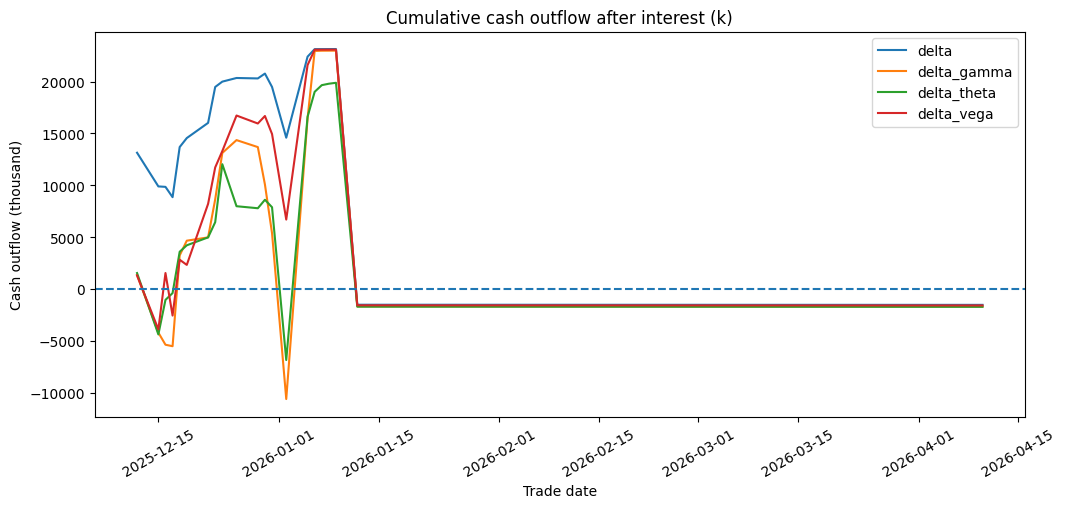

In [14]:
plt.figure(figsize=(12, 5))

for strategy_name, sub in combined_history_df.groupby("strategy"):
    sub = sub.sort_values("trade_date")
    plt.plot(
        sub["trade_date"],
        sub["cumulative_cash_outflow_after_interest"] / 1000.0,
        label=strategy_name,
    )

plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after interest (k)")
plt.xlabel("Trade date")
plt.ylabel("Cash outflow (thousand)")
plt.legend()
plt.xticks(rotation=30)
plt.show()


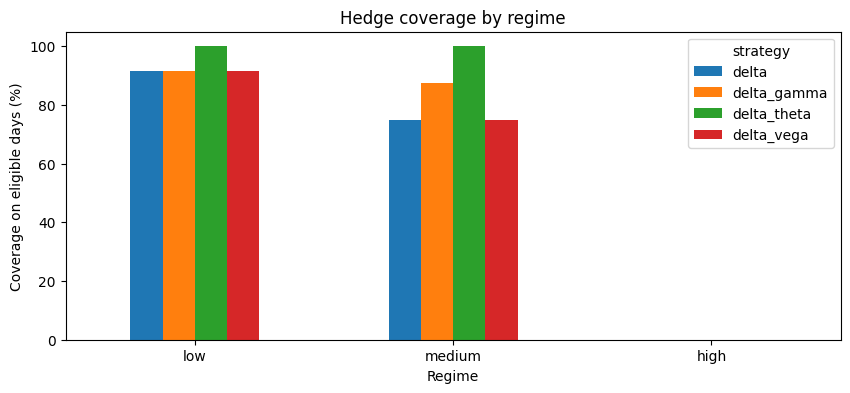

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_48455/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


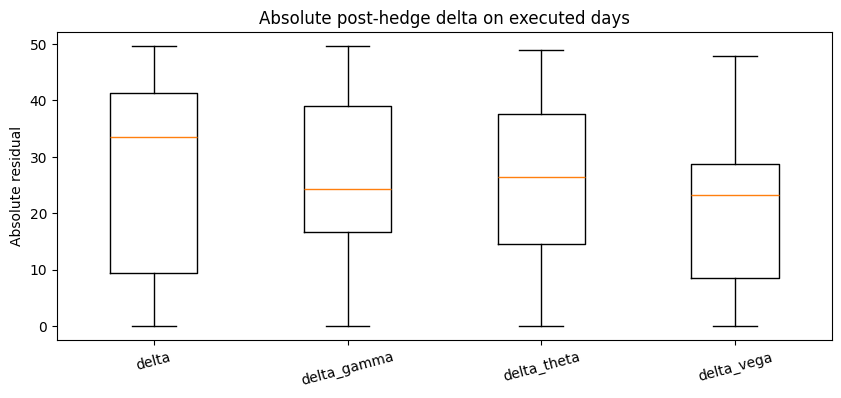

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_48455/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


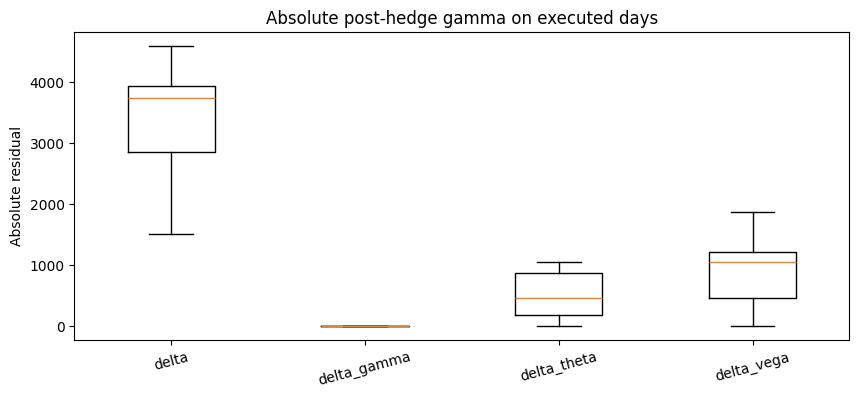

/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_48455/1876050143.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


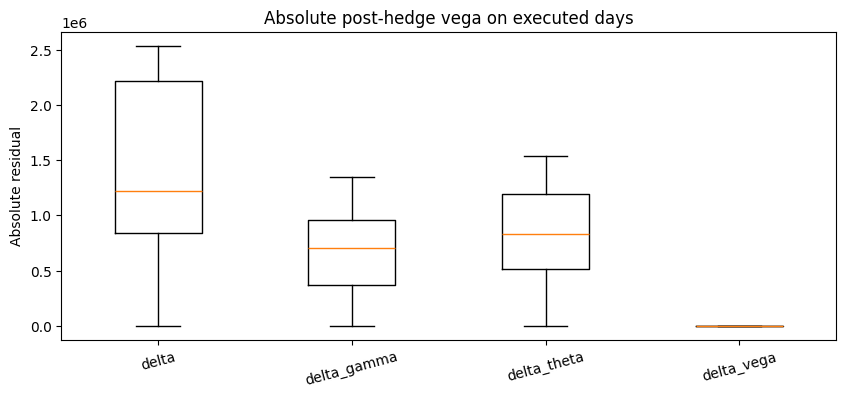

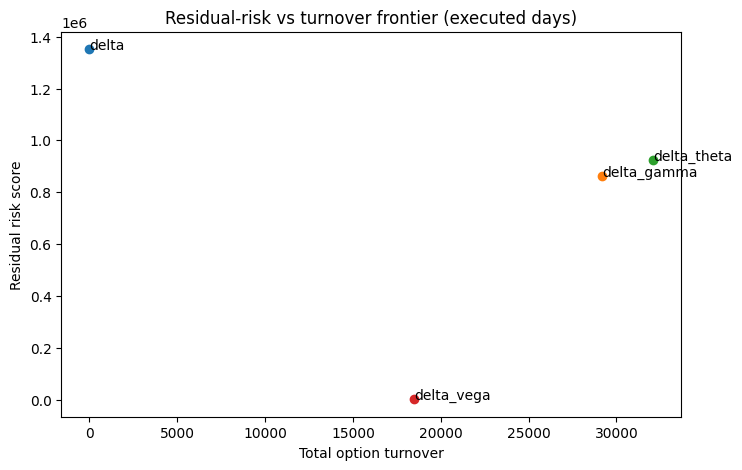

In [15]:
coverage_plot_df = build_hedge_coverage_table(combined_history_df)
coverage_pivot = coverage_plot_df.pivot(index="regime", columns="strategy", values="hedge_coverage_pct")
coverage_pivot = coverage_pivot.reindex(index=["low", "medium", "high"])
coverage_pivot.plot(kind="bar", figsize=(10, 4))
plt.title("Hedge coverage by regime")
plt.xlabel("Regime")
plt.ylabel("Coverage on eligible days (%)")
plt.xticks(rotation=0)
plt.show()

executed_history_df = hedge_executed_days_only(combined_history_df)

greeks_to_plot = [
    ("post_delta", "Absolute post-hedge delta on executed days"),
    ("post_gamma", "Absolute post-hedge gamma on executed days"),
    ("post_vega", "Absolute post-hedge vega on executed days"),
]

for greek_col, title_text in greeks_to_plot:
    plt.figure(figsize=(10, 4))
    box_data = []
    labels = []
    for strat in sorted(executed_history_df["strategy"].dropna().unique()):
        strat_values = executed_history_df.loc[
            executed_history_df["strategy"] == strat, greek_col
        ].abs().dropna().to_numpy()
        if len(strat_values) > 0:
            box_data.append(strat_values)
            labels.append(strat)

    if len(box_data) > 0:
        plt.boxplot(box_data, labels=labels, showfliers=False)
        plt.title(title_text)
        plt.ylabel("Absolute residual")
        plt.xticks(rotation=15)
        plt.show()

frontier_df = compute_effectiveness_metrics(combined_history_df, sample_view="executed").reset_index()
frontier_df = frontier_df.dropna(subset=["residual_risk_score", "total_option_turnover"])

plt.figure(figsize=(8, 5))
for _, row in frontier_df.iterrows():
    plt.scatter(row["total_option_turnover"], row["residual_risk_score"])
    plt.text(row["total_option_turnover"], row["residual_risk_score"], row["strategy"])

plt.title("Residual-risk vs turnover frontier (executed days)")
plt.xlabel("Total option turnover")
plt.ylabel("Residual risk score")
plt.show()


## 12. Optional: inspect one regime in more detail


In [16]:
chosen_regime = "high"

print(f"=== Coverage diagnostics for regime: {chosen_regime} ===")
display(
    coverage_df.loc[coverage_df["regime"] == chosen_regime].sort_values("strategy")
)

print(f"=== All evaluation-day summary for regime: {chosen_regime} ===")
display(
    regime_summary_df.loc[regime_summary_df["regime"] == chosen_regime].sort_values("strategy")
)

print(f"=== Executed-day-only summary for regime: {chosen_regime} ===")
display(
    executed_summary_df.loc[executed_summary_df["regime"] == chosen_regime].sort_values("strategy")
)


=== Coverage diagnostics for regime: high ===


,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,eligibility_pct_of_regime,execution_pct_of_regime,hedge_coverage_pct,top_no_hedge_reason
0,delta,high,14,0,0,0.0,0.0,NaN,no_live_exposure
3,delta_gamma,high,14,0,0,0.0,0.0,NaN,no_live_exposure
6,delta_theta,high,14,0,0,0.0,0.0,NaN,no_live_exposure
9,delta_vega,high,14,0,0,0.0,0.0,NaN,no_live_exposure


=== All evaluation-day summary for regime: high ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,0,0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,-1.521637e+06,0.0
3,regime,delta_gamma,high,14,0,0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,-1.676609e+06,0.0
6,regime,delta_theta,high,14,0,0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,-1.710350e+06,0.0
9,regime,delta_vega,high,14,0,0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,0.0,-1.578061e+06,0.0


=== Executed-day-only summary for regime: high ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,executed,delta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,executed,delta_gamma,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,executed,delta_theta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,executed,delta_vega,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 13. DGV extension and integration notes

The DGV deep-dive below can now plug into the same **coverage-aware** reporting layer used for the initial four strategies.

### Integration principle
When DGV is appended to the unified comparison table, make sure it exposes the same interpretability fields:

- `regime_evaluation_day`
- `hedge_eligible_day`
- `hedge_executed_day`
- `no_hedge_reason`

That way DGV can be compared fairly not only on residual Greeks, but also on **coverage**, **turnover**, and **feasibility under stress**.


---
## Section 13: Delta-Gamma-Vega (DGV) Deep-Dive

The DGV strategy is the most advanced contribution of this notebook. It solves a
two-leg hedge simultaneously targeting delta, gamma, and vega neutrality using a
discrete linear programming approximation.

### Key design choices
- **Two hedge legs**: one short-dated (7–14 DTE) and one longer-dated (60–90 DTE) option
- **Rolling base cycles**: the 30-DTE base position is rolled every month
- **Inventory cap**: gross option inventory capped at 3,000 contracts to maintain
  a controlled, presentation-realistic hedge book
- **Trade-off**: tighter inventory caps slightly reduce hedge precision (higher residual
  Greeks) but produce a more defensible, interpretable book for academic purposes


## 1. User inputs

You can change the ticker, sample length, entry maturity, hedge-bucket ranges, and stability settings here.

### Important interpretation used here
- Base position on day 1: **short ATM call**
- Size: **100,000 shares equivalent**
- Contract multiplier: **100 shares per option contract**
- Initial base option position: **-1,000 contracts**
- One hedge option is chosen from a **shorter DTE bucket**
- One hedge option is chosen from a **longer DTE bucket**
- The simulation stops on the **base option expiry date**


In [17]:
# ---------------------------------------------------
# Data and sample settings
# ---------------------------------------------------
TICKER = "AMZN"
MONTHS = 4
END_DATE = None                 # e.g. "2026-03-31"

# ---------------------------------------------------
# Base position settings
# ---------------------------------------------------
N_UNDERLYING_SHARES = 100_000
CONTRACT_MULTIPLIER = 100
BASE_OPTION_TYPE = "call"       # "call" or "put"
BASE_POSITION_SIGN = -1         # -1 = short, +1 = long
TARGET_ENTRY_DTE = 30

# ---------------------------------------------------
# Hedge settings
# ---------------------------------------------------
# SHORT_HEDGE_DTE_RANGE = (14, 21)
# LONG_HEDGE_DTE_RANGE = (45, 60)
# MAX_NEW_CANDIDATES_PER_BUCKET = 6
# CONDITION_NUMBER_LIMIT = 500

# Search around the clipped theoretical option hedge trade
OPTION_SEARCH_RADIUS = 2
STOCK_ROUND_LOT = 100

# Hard position / trade caps
MAX_ABS_OPTION_TRADE = 3000
MAX_ABS_STOCK_POSITION = 150_000
MAX_GROSS_OPTION_CONTRACTS = 5000

SHORT_HEDGE_DTE_RANGE = (7, 14)
LONG_HEDGE_DTE_RANGE = (60, 90)
MAX_NEW_CANDIDATES_PER_BUCKET = 12
CONDITION_NUMBER_LIMIT = 50000

# Loss weights for residual Greeks after actual trade selection
DELTA_WEIGHT = 1.0
GAMMA_WEIGHT = 1.0
VEGA_WEIGHT = 1.0

# Penalties to keep actual trades near theoretical trades and discourage inventory build-up
QUANTITY_PENALTY = 0.05
TURNOVER_PENALTY = 0.01
INVENTORY_PENALTY_WEIGHT = 0.02

# Synthetic IV settings (same logic as helper file)
SMILE_STRENGTH = 0.30
TERM_SLOPE = 0.08

# Cash carry / interest settings
TRADING_DAYS_PER_YEAR = 252
USE_DAILY_RISK_FREE_RATE_FOR_CASH = True
MANUAL_CASH_RATE = 0.05         # used only if the flag above is False

EPS = 1e-12

BASE_CONTRACTS = int(BASE_POSITION_SIGN * (N_UNDERLYING_SHARES / CONTRACT_MULTIPLIER))
print("Base option contracts on day 1:", BASE_CONTRACTS)


Base option contracts on day 1: -1000


## 2. Load the synthetic market dataset
This calls your helper module and pulls:
- stock history
- VIX history
- rates
- merged daily inputs
- synthetic option chain

In [18]:
dataset = build_synthetic_market_dataset(
    ticker=TICKER,
    months=MONTHS,
    end_date=END_DATE,
    expiry_days=(7, 14, 21, 30, 45, 60, 90, 120, 150, 180)
,
)

stock_df = dataset["stock_history"].copy()
vix_df = dataset["vix_history"].copy()
rates_df = dataset["risk_free_history"].copy()
merged_df = dataset["merged_daily_inputs"].copy()
raw_chain_df = dataset["synthetic_option_chain"].copy()

merged_df["date"] = pd.to_datetime(merged_df["date"])
raw_chain_df["trade_date"] = pd.to_datetime(raw_chain_df["trade_date"])
raw_chain_df["expiry"] = pd.to_datetime(raw_chain_df["expiry"])

print("Merged daily inputs shape:", merged_df.shape)
print("Raw synthetic chain shape:", raw_chain_df.shape)

display(merged_df.head())
display(raw_chain_df.head())

Merged daily inputs shape: (81, 11)
Raw synthetic chain shape: (31940, 19)


,date,open,high,low,close,volume,vix_close,risk_free_rate_pct,risk_free_rate,realized_vol_21d,base_iv
0,2025-12-12,229.869995,230.080002,225.119995,226.190002,35639100,15.740000,3.525,0.03525,NaN,0.1574
1,2025-12-15,227.929993,227.929993,221.500000,222.539993,47286100,16.500000,3.538,0.03538,NaN,0.1650
2,2025-12-16,223.039993,223.660004,221.130005,222.559998,39298900,16.480000,3.545,0.03545,NaN,0.1648
3,2025-12-17,224.660004,225.190002,220.990005,221.270004,44034400,17.620001,3.543,0.03543,NaN,0.1762
4,2025-12-18,225.710007,229.229996,224.410004,226.759995,50272400,16.870001,3.522,0.03522,NaN,0.1687


,trade_date,ticker,spot,expiry,dte,strike,option_type,risk_free_rate,vix_close,base_iv,synthetic_iv,theoretical_price,intrinsic_value,time_value,delta,gamma,vega,theta,rho
0,2025-12-12,AMZN,226.19,2025-12-19,7,180.0,call,0.03525,15.74,0.1574,0.171159,46.311646,46.190002,0.121644,1.0,0.0,0.000000,-6.340712,3.449722
1,2025-12-12,AMZN,226.19,2025-12-19,7,185.0,call,0.03525,15.74,0.1574,0.163531,41.315025,41.190002,0.125023,1.0,0.0,0.000000,-6.516843,3.545548
2,2025-12-12,AMZN,226.19,2025-12-19,7,190.0,call,0.03525,15.74,0.1574,0.170146,36.318404,36.190002,0.128402,1.0,0.0,0.000000,-6.692974,3.641373
3,2025-12-12,AMZN,226.19,2025-12-19,7,195.0,call,0.03525,15.74,0.1574,0.177687,31.321783,31.190002,0.131781,1.0,0.0,0.000000,-6.869105,3.737199
4,2025-12-12,AMZN,226.19,2025-12-19,7,200.0,call,0.03525,15.74,0.1574,0.158934,26.325162,26.190002,0.135160,1.0,0.0,0.000002,-7.045242,3.833024


## 3. Rebuild a persistent option panel

The raw synthetic chain is generated independently for each date.  
For iterative rebalancing, we need the same contract to be repriced across later dates.

So we:
1. take the union of all contracts seen in the raw chain
2. create a stable `contract_id = expiry | strike | option_type`
3. reprice every live contract on every trade date using the same Black-Scholes helper functions

In [19]:
def synthetic_iv_from_inputs(spot, strike, time_to_expiry, base_iv, smile_strength=0.30, term_slope=0.08):
    if time_to_expiry <= 0:
        return np.nan

    log_moneyness = np.log(strike / spot)
    smile_adjustment = 1.0 + smile_strength * abs(log_moneyness)
    term_adjustment = 1.0 + term_slope * (np.sqrt(time_to_expiry) - np.sqrt(30 / 365.0))

    sigma = base_iv * smile_adjustment * term_adjustment
    sigma = float(np.clip(sigma, 0.05, 2.00))
    return sigma


def build_persistent_option_panel(merged_daily_inputs, raw_chain, smile_strength=0.30, term_slope=0.08):
    contract_master = (
        raw_chain[["expiry", "strike", "option_type"]]
        .drop_duplicates()
        .sort_values(["expiry", "option_type", "strike"])
        .reset_index(drop=True)
        .copy()
    )

    contract_master["contract_id"] = (
        contract_master["expiry"].dt.strftime("%Y-%m-%d")
        + "|"
        + contract_master["strike"].round(2).astype(str)
        + "|"
        + contract_master["option_type"]
    )

    rows = []

    daily_inputs = merged_daily_inputs.copy().sort_values("date")

    for _, day_row in daily_inputs.iterrows():
        trade_date = pd.Timestamp(day_row["date"])
        spot = float(day_row["close"])
        r = float(day_row["risk_free_rate"])
        base_iv = float(day_row["base_iv"])

        live_contracts = contract_master.loc[contract_master["expiry"] >= trade_date].copy()

        for _, c in live_contracts.iterrows():
            expiry = pd.Timestamp(c["expiry"])
            strike = float(c["strike"])
            option_type = c["option_type"]
            contract_id = c["contract_id"]

            dte_days = (expiry - trade_date).days
            T = dte_days / 365.0

            sigma = synthetic_iv_from_inputs(
                spot=spot,
                strike=strike,
                time_to_expiry=T,
                base_iv=base_iv,
                smile_strength=smile_strength,
                term_slope=term_slope,
            )

            price = black_scholes_price(spot, strike, T, r, sigma, option_type=option_type)
            delta, gamma, vega, theta, rho = black_scholes_greeks(
                spot, strike, T, r, sigma, option_type=option_type
            )

            rows.append(
                {
                    "trade_date": trade_date,
                    "contract_id": contract_id,
                    "expiry": expiry,
                    "dte": dte_days,
                    "strike": strike,
                    "option_type": option_type,
                    "spot": spot,
                    "risk_free_rate": r,
                    "base_iv": base_iv,
                    "synthetic_iv": sigma,
                    "theoretical_price": price,
                    "delta": delta,
                    "gamma": gamma,
                    "vega": vega,
                    "theta": theta,
                    "rho": rho,
                }
            )

    panel = (
        pd.DataFrame(rows)
        .sort_values(["trade_date", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )
    return panel


panel_df = build_persistent_option_panel(
    merged_daily_inputs=merged_df,
    raw_chain=raw_chain_df,
    smile_strength=SMILE_STRENGTH,
    term_slope=TERM_SLOPE,
)

print("Persistent option panel shape:", panel_df.shape)
display(panel_df.head())


Persistent option panel shape: (881808, 16)


,trade_date,contract_id,expiry,dte,strike,option_type,spot,risk_free_rate,base_iv,synthetic_iv,theoretical_price,delta,gamma,vega,theta,rho
0,2025-12-12,2025-12-19|180.0|call,2025-12-19,7,180.0,call,226.190002,0.03525,0.1574,0.166192,46.311646,1.0,2.083333e-23,3.397194e-21,-6.340712,3.449722
1,2025-12-12,2025-12-19|185.0|call,2025-12-19,7,185.0,call,226.190002,0.03525,0.1574,0.164913,41.315025,1.0,8.076141e-19,1.306808e-16,-6.516843,3.545548
2,2025-12-12,2025-12-19|190.0|call,2025-12-19,7,190.0,call,226.190002,0.03525,0.1574,0.163669,36.318404,1.0,8.022058e-15,1.288262e-12,-6.692974,3.641373
3,2025-12-12,2025-12-19|195.0|call,2025-12-19,7,195.0,call,226.190002,0.03525,0.1574,0.162457,31.321783,1.0,2.141503e-11,3.413573e-09,-6.869105,3.737199
4,2025-12-12,2025-12-19|200.0|call,2025-12-19,7,200.0,call,226.190002,0.03525,0.1574,0.161276,26.325162,1.0,1.605947e-08,2.541278e-06,-7.045246,3.833024


## 4. Helper functions

These helpers:
- choose the day-1 ATM base contract
- compute portfolio Greeks using option contracts and stock shares
- build a daily hedge universe from:
  - currently held hedge contracts
  - fresh short-dated candidates
  - fresh longer-dated candidates
- solve the continuous theoretical DGV hedge
- convert it into an actual discrete trade under conditioning and inventory caps


In [20]:
def choose_initial_atm_contract(day_panel, target_dte=30, option_type="call"):
    df = day_panel.loc[day_panel["option_type"] == option_type].copy()
    df["atm_distance"] = (df["strike"] - df["spot"]).abs()
    df["dte_distance"] = (df["dte"] - target_dte).abs()

    chosen = (
        df.sort_values(["atm_distance", "dte_distance", "expiry", "strike"])
        .iloc[0]
    )
    return chosen


def clean_position_book(position_book, day_panel):
    live_ids = set(day_panel["contract_id"].unique())
    cleaned = {
        cid: qty
        for cid, qty in position_book.items()
        if (cid in live_ids) and (abs(qty) > EPS)
    }
    return cleaned


def round_to_lot(x, lot_size=100):
    if not np.isfinite(x):
        return 0.0
    return float(np.round(x / lot_size) * lot_size)


def portfolio_snapshot(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
    df = day_panel.set_index("contract_id")

    rows = []
    total_delta = float(stock_position)
    total_gamma = 0.0
    total_vega = 0.0
    total_theta = 0.0
    total_option_value = 0.0

    for cid, qty_contracts in option_positions.items():
        if cid not in df.index:
            continue

        row = df.loc[cid]
        qty_shares_equiv = qty_contracts * contract_multiplier

        pos_delta = qty_shares_equiv * float(row["delta"])
        pos_gamma = qty_shares_equiv * float(row["gamma"])
        pos_vega = qty_shares_equiv * float(row["vega"])
        pos_theta = qty_shares_equiv * float(row["theta"])
        pos_value = qty_shares_equiv * float(row["theoretical_price"])

        rows.append(
            {
                "contract_id": cid,
                "quantity_contracts": qty_contracts,
                "quantity_shares_equiv": qty_shares_equiv,
                "price_per_share": float(row["theoretical_price"]),
                "delta_per_share": float(row["delta"]),
                "gamma_per_share": float(row["gamma"]),
                "vega_per_share": float(row["vega"]),
                "theta_per_share": float(row["theta"]),
                "position_delta": pos_delta,
                "position_gamma": pos_gamma,
                "position_vega": pos_vega,
                "position_theta": pos_theta,
                "position_value": pos_value,
            }
        )

        total_delta += pos_delta
        total_gamma += pos_gamma
        total_vega += pos_vega
        total_theta += pos_theta
        total_option_value += pos_value

    details = pd.DataFrame(rows)

    summary = {
        "stock_position_shares": float(stock_position),
        "option_value": float(total_option_value),
        "total_delta": float(total_delta),
        "total_gamma": float(total_gamma),
        "total_vega": float(total_vega),
        "total_theta": float(total_theta),
    }
    return summary, details


def select_current_hedge_candidates(
    day_panel,
    option_positions,
    exclude_contract_ids=None,
    short_long_split_dte=30,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    held_ids = [
        cid
        for cid, qty in option_positions.items()
        if (abs(qty) > EPS) and (cid not in exclude_contract_ids)
    ]

    if not held_ids:
        return pd.DataFrame(), pd.DataFrame()

    held = day_panel.loc[day_panel["contract_id"].isin(held_ids)].copy()
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held = held.replace([np.inf, -np.inf], np.nan)
    held = held.dropna(subset=[col for col in ["dte", "gamma", "vega", "delta", "theoretical_price"] if col in held.columns])
    if len(held) == 0:
        return pd.DataFrame(), pd.DataFrame()

    held["candidate_score"] = -1.0

    short_candidates = held.loc[held["dte"] <= short_long_split_dte].copy()
    long_candidates = held.loc[held["dte"] > short_long_split_dte].copy()

    return short_candidates.reset_index(drop=True), long_candidates.reset_index(drop=True)


def select_bucket_candidates(day_panel, dte_range, max_candidates=6, exclude_contract_ids=None):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    lower_dte, upper_dte = dte_range

    df = day_panel.copy()
    df = df.loc[~df["contract_id"].isin(exclude_contract_ids)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[col for col in ["dte", "strike", "spot", "gamma", "vega", "delta", "theoretical_price"] if col in df.columns])
    df = df.loc[df["dte"].between(lower_dte, upper_dte)].copy()
    df = df.loc[(df["gamma"].abs() > 1e-12) & (df["vega"].abs() > 1e-12)].copy()

    if len(df) == 0:
        return df.reset_index(drop=True)

    target_dte = 0.5 * (lower_dte + upper_dte)
    df["atm_score"] = np.abs(np.log(df["strike"] / df["spot"]))
    df["dte_score"] = np.abs(df["dte"] - target_dte) / 365.0
    df["candidate_score"] = df["atm_score"] + 0.50 * df["dte_score"]

    return (
        df.sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .head(max_candidates)
        .reset_index(drop=True)
    )


def combine_candidate_frames(*frames):
    usable_frames = [frame.copy() for frame in frames if frame is not None and len(frame) > 0]
    if not usable_frames:
        return pd.DataFrame()

    combined = pd.concat(usable_frames, ignore_index=True)
    if "candidate_score" not in combined.columns:
        combined["candidate_score"] = 0.0
    combined["candidate_score"] = combined["candidate_score"].fillna(-1.0)
    combined = combined.replace([np.inf, -np.inf], np.nan)
    combined = combined.dropna(subset=[col for col in ["gamma", "vega", "delta", "theoretical_price", "candidate_score"] if col in combined.columns])

    if len(combined) == 0:
        return combined.reset_index(drop=True)

    return (
        combined
        .drop_duplicates(subset=["contract_id"], keep="first")
        .sort_values(["candidate_score", "expiry", "option_type", "strike"])
        .reset_index(drop=True)
    )


def apply_option_trades(option_positions, option_trade_map):
    updated = {
        cid: float(qty)
        for cid, qty in option_positions.items()
        if abs(qty) > EPS
    }

    for cid, trade_qty in option_trade_map.items():
        updated[cid] = updated.get(cid, 0.0) + float(trade_qty)

    return {
        cid: qty
        for cid, qty in updated.items()
        if abs(qty) > EPS
    }


def gross_option_contracts(option_positions):
    return float(sum(abs(qty) for qty in option_positions.values()))


def hedge_objective(
    residual_delta,
    residual_gamma,
    residual_vega,
    delta_scale,
    gamma_scale,
    vega_scale,
    q_a_actual,
    q_b_actual,
    q_stock_actual,
    q_a_theory,
    q_b_theory,
    q_stock_theory,
    post_option_positions,
    post_stock_position,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
):
    greek_loss = (
        DELTA_WEIGHT * (residual_delta / max(delta_scale, 1.0)) ** 2
        + GAMMA_WEIGHT * (residual_gamma / max(gamma_scale, 1e-8)) ** 2
        + VEGA_WEIGHT * (residual_vega / max(vega_scale, 1e-8)) ** 2
    )

    quantity_gap = (
        (q_a_actual - q_a_theory) ** 2
        + (q_b_actual - q_b_theory) ** 2
        + ((q_stock_actual - q_stock_theory) / max(STOCK_ROUND_LOT, 1.0)) ** 2
    )

    turnover = (
        abs(q_a_actual)
        + abs(q_b_actual)
        + abs(q_stock_actual) / max(STOCK_ROUND_LOT, 1.0)
    )

    inventory_penalty = (
        abs(post_stock_position) / max(STOCK_ROUND_LOT, 1.0)
        + sum(abs(qty) for qty in post_option_positions.values())
    )

    return (
        greek_loss
        + quantity_penalty * quantity_gap
        + turnover_penalty * turnover
        + inventory_penalty_weight * inventory_penalty
    )


def find_best_daily_rebalance(
    day_panel,
    option_positions,
    stock_position,
    exclude_contract_ids=None,
    max_new_candidates_per_bucket=6,
    short_dte_range=(14, 21),
    long_dte_range=(45, 60),
    option_search_radius=2,
    condition_number_limit=500,
    quantity_penalty=0.05,
    turnover_penalty=0.01,
    inventory_penalty_weight=0.02,
    max_abs_option_trade=3000,
    max_abs_stock_position=150_000,
    max_gross_option_contracts=5000,
    contract_multiplier=100,
):
    if exclude_contract_ids is None:
        exclude_contract_ids = set()

    pre_summary, _ = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=contract_multiplier,
    )

    short_long_split_dte = 0.5 * (short_dte_range[1] + long_dte_range[0])

    current_short_candidates, current_long_candidates = select_current_hedge_candidates(
        day_panel=day_panel,
        option_positions=option_positions,
        exclude_contract_ids=exclude_contract_ids,
        short_long_split_dte=short_long_split_dte,
    )

    fresh_short_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=short_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )
    fresh_long_candidates = select_bucket_candidates(
        day_panel=day_panel,
        dte_range=long_dte_range,
        max_candidates=max_new_candidates_per_bucket,
        exclude_contract_ids=exclude_contract_ids,
    )

    short_candidates = combine_candidate_frames(current_short_candidates, fresh_short_candidates)
    long_candidates = combine_candidate_frames(current_long_candidates, fresh_long_candidates)

    if (len(short_candidates) == 0) or (len(long_candidates) == 0):
        return None

    best = None
    short_rows = list(short_candidates.to_dict("records"))
    long_rows = list(long_candidates.to_dict("records"))

    delta_scale = max(abs(pre_summary["total_delta"]), N_UNDERLYING_SHARES, 1.0)
    gamma_scale = max(abs(pre_summary["total_gamma"]), 1.0)
    vega_scale = max(abs(pre_summary["total_vega"]), 1.0)

    for row_a in short_rows:
        for row_b in long_rows:
            if row_a["contract_id"] == row_b["contract_id"]:
                continue

            A = np.array(
                [
                    [contract_multiplier * row_a["gamma"], contract_multiplier * row_b["gamma"]],
                    [contract_multiplier * row_a["vega"], contract_multiplier * row_b["vega"]],
                ],
                dtype=float,
            )

            if not np.all(np.isfinite(A)):
                continue

            try:
                cond_number = np.linalg.cond(A)
            except np.linalg.LinAlgError:
                continue
            if (not np.isfinite(cond_number)) or (cond_number > condition_number_limit):
                continue

            b = -np.array(
                [pre_summary["total_gamma"], pre_summary["total_vega"]],
                dtype=float,
            )

            try:
                q_theory = np.linalg.solve(A, b)
            except np.linalg.LinAlgError:
                continue
            if not np.all(np.isfinite(q_theory)):
                continue

            q_a_theory = float(np.clip(q_theory[0], -max_abs_option_trade, max_abs_option_trade))
            q_b_theory = float(np.clip(q_theory[1], -max_abs_option_trade, max_abs_option_trade))

            q_stock_theory = -(
                pre_summary["total_delta"]
                + contract_multiplier * row_a["delta"] * q_a_theory
                + contract_multiplier * row_b["delta"] * q_b_theory
            )
            post_stock_theory = float(
                np.clip(stock_position + q_stock_theory, -max_abs_stock_position, max_abs_stock_position)
            )
            q_stock_theory = float(post_stock_theory - stock_position)
            if not all(np.isfinite(v) for v in [q_a_theory, q_b_theory, q_stock_theory]):
                continue

            q_a_center = int(np.round(q_a_theory))
            q_b_center = int(np.round(q_b_theory))

            q_a_min = max(-max_abs_option_trade, q_a_center - option_search_radius)
            q_a_max = min(max_abs_option_trade, q_a_center + option_search_radius)
            q_b_min = max(-max_abs_option_trade, q_b_center - option_search_radius)
            q_b_max = min(max_abs_option_trade, q_b_center + option_search_radius)

            q_a_grid = range(q_a_min, q_a_max + 1)
            q_b_grid = range(q_b_min, q_b_max + 1)

            for q_a_actual in q_a_grid:
                for q_b_actual in q_b_grid:
                    raw_stock_trade = -(
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                    )
                    post_stock_position = round_to_lot(
                        np.clip(
                            stock_position + raw_stock_trade,
                            -max_abs_stock_position,
                            max_abs_stock_position,
                        ),
                        lot_size=STOCK_ROUND_LOT,
                    )
                    post_stock_position = float(
                        np.clip(post_stock_position, -max_abs_stock_position, max_abs_stock_position)
                    )
                    q_stock_actual = float(post_stock_position - stock_position)

                    post_option_positions = apply_option_trades(
                        option_positions,
                        {
                            row_a["contract_id"]: float(q_a_actual),
                            row_b["contract_id"]: float(q_b_actual),
                        },
                    )
                    gross_contracts = gross_option_contracts(post_option_positions)
                    if gross_contracts > max_gross_option_contracts:
                        continue

                    residual_delta = (
                        pre_summary["total_delta"]
                        + contract_multiplier * row_a["delta"] * q_a_actual
                        + contract_multiplier * row_b["delta"] * q_b_actual
                        + q_stock_actual
                    )
                    residual_gamma = (
                        pre_summary["total_gamma"]
                        + contract_multiplier * row_a["gamma"] * q_a_actual
                        + contract_multiplier * row_b["gamma"] * q_b_actual
                    )
                    residual_vega = (
                        pre_summary["total_vega"]
                        + contract_multiplier * row_a["vega"] * q_a_actual
                        + contract_multiplier * row_b["vega"] * q_b_actual
                    )
                    if not all(np.isfinite(v) for v in [residual_delta, residual_gamma, residual_vega, post_stock_position]):
                        continue

                    objective = hedge_objective(
                        residual_delta=residual_delta,
                        residual_gamma=residual_gamma,
                        residual_vega=residual_vega,
                        delta_scale=delta_scale,
                        gamma_scale=gamma_scale,
                        vega_scale=vega_scale,
                        q_a_actual=q_a_actual,
                        q_b_actual=q_b_actual,
                        q_stock_actual=q_stock_actual,
                        q_a_theory=q_a_theory,
                        q_b_theory=q_b_theory,
                        q_stock_theory=q_stock_theory,
                        post_option_positions=post_option_positions,
                        post_stock_position=post_stock_position,
                        quantity_penalty=quantity_penalty,
                        turnover_penalty=turnover_penalty,
                        inventory_penalty_weight=inventory_penalty_weight,
                    )
                    if not np.isfinite(objective):
                        continue

                    candidate = {
                        "contract_a": row_a["contract_id"],
                        "contract_b": row_b["contract_id"],
                        "row_a": row_a,
                        "row_b": row_b,
                        "q_a_theory": q_a_theory,
                        "q_b_theory": q_b_theory,
                        "q_stock_theory": float(q_stock_theory),
                        "q_a_actual": float(q_a_actual),
                        "q_b_actual": float(q_b_actual),
                        "q_stock_actual": float(q_stock_actual),
                        "post_stock_position": float(post_stock_position),
                        "post_option_positions": post_option_positions,
                        "gross_option_contracts_after_trade": float(gross_contracts),
                        "post_delta_residual": float(residual_delta),
                        "post_gamma_residual": float(residual_gamma),
                        "post_vega_residual": float(residual_vega),
                        "condition_number": float(cond_number),
                        "objective": float(objective),
                    }

                    if (best is None) or (candidate["objective"] < best["objective"]):
                        best = candidate

    return best


## 5. Run the daily DGV hedging simulation

### Base book on day 1
We start with a **short ATM call** whose total underlying equivalent is **100,000 shares**.

### Horizon and roll convention
- rebalance through the **latest available trade date** in the dataset
- when the current base option reaches expiry, liquidate the existing book, open a fresh ATM base contract, and continue hedging on the same day
- the final row therefore shows the live hedged book on the most recent trade date rather than stopping at the first base expiry

### Rebalancing logic
On each trade date:
1. liquidate and roll the base book if the active cycle has expired
2. value the carried actual book after any new base entry
3. build a hedge universe from:
   - currently held hedge contracts
   - fresh short-dated candidates
   - fresh longer-dated candidates
4. solve the **continuous theoretical DGV-neutral hedge**
5. convert it into **capped discrete trades**
6. apply the trades and record the daily table


In [21]:
all_dates = [pd.Timestamp(trade_date) for trade_date in sorted(panel_df["trade_date"].unique())]
first_date = all_dates[0]

day1_panel = panel_df.loc[panel_df["trade_date"] == first_date].copy()

preview_contract = choose_initial_atm_contract(
    day_panel=day1_panel,
    target_dte=TARGET_ENTRY_DTE,
    option_type=BASE_OPTION_TYPE,
)

print("Chosen base contract on day 1:")
display(
    preview_contract.to_frame().T[
        [
            "trade_date", "expiry", "dte", "strike", "option_type",
            "contract_id", "theoretical_price", "delta", "gamma", "vega"
        ]
    ]
)
print("Simulation rebalances through latest available trade date:", all_dates[-1].date())

current_base_contract_id = None
current_base_expiry = None
base_cycle_index = 0

# Position book stores quantities in option contracts
option_positions = {}
stock_position = 0.0

cumulative_cash_after_interest = 0.0

history_rows = []
trade_log_rows = []

for trade_date in all_dates:
    day_panel = panel_df.loc[panel_df["trade_date"] == trade_date].copy()
    active_contract_ids = set(day_panel["contract_id"])
    spot_t = float(day_panel["spot"].iloc[0])
    r_cash_t = float(day_panel["risk_free_rate"].iloc[0]) if USE_DAILY_RISK_FREE_RATE_FOR_CASH else MANUAL_CASH_RATE

    option_positions = clean_position_book(option_positions, day_panel)

    base_trade_contracts = 0.0
    base_trade_cashflow = 0.0
    hedge_option_trade_cashflow = 0.0
    stock_trade_cashflow = 0.0
    option_liquidation_cashflow = 0.0
    stock_liquidation_cashflow = 0.0
    liquidation_applied = False
    is_base_entry_day = False

    q_a_actual = 0.0
    q_b_actual = 0.0
    q_stock_actual = 0.0
    q_a_theory = np.nan
    q_b_theory = np.nan
    q_stock_theory = np.nan
    contract_a = None
    contract_b = None
    condition_number = np.nan
    objective = np.nan
    gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    is_base_expiry_day = (
        current_base_contract_id is not None
        and (
            trade_date >= current_base_expiry
            or current_base_contract_id not in active_contract_ids
        )
    )

    if is_base_expiry_day:
        liquidation_applied = True

        for cid, qty in list(option_positions.items()):
            if cid not in active_contract_ids:
                continue
            row = day_panel.loc[day_panel["contract_id"] == cid].iloc[0]
            option_liquidation_cashflow += (-qty) * CONTRACT_MULTIPLIER * float(row["theoretical_price"])

        stock_liquidation_cashflow = (-stock_position) * spot_t
        option_positions = {}
        stock_position = 0.0
        gross_option_contracts_after_trade = 0.0

    if current_base_contract_id is None or liquidation_applied:
        entry_contract = choose_initial_atm_contract(
            day_panel=day_panel,
            target_dte=TARGET_ENTRY_DTE,
            option_type=BASE_OPTION_TYPE,
        )

        current_base_contract_id = entry_contract["contract_id"]
        current_base_expiry = pd.Timestamp(entry_contract["expiry"])
        base_cycle_index += 1

        option_positions = {current_base_contract_id: float(BASE_CONTRACTS)}
        base_trade_contracts = float(BASE_CONTRACTS)
        base_trade_cashflow = base_trade_contracts * CONTRACT_MULTIPLIER * float(entry_contract["theoretical_price"])
        is_base_entry_day = True

    base_row = day_panel.loc[day_panel["contract_id"] == current_base_contract_id].iloc[0]

    pre_summary, pre_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    rebalance = find_best_daily_rebalance(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        exclude_contract_ids={current_base_contract_id},
        max_new_candidates_per_bucket=MAX_NEW_CANDIDATES_PER_BUCKET,
        short_dte_range=SHORT_HEDGE_DTE_RANGE,
        long_dte_range=LONG_HEDGE_DTE_RANGE,
        option_search_radius=OPTION_SEARCH_RADIUS,
        condition_number_limit=CONDITION_NUMBER_LIMIT,
        quantity_penalty=QUANTITY_PENALTY,
        turnover_penalty=TURNOVER_PENALTY,
        inventory_penalty_weight=INVENTORY_PENALTY_WEIGHT,
        max_abs_option_trade=MAX_ABS_OPTION_TRADE,
        max_abs_stock_position=MAX_ABS_STOCK_POSITION,
        max_gross_option_contracts=MAX_GROSS_OPTION_CONTRACTS,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    if rebalance is not None:
        contract_a = rebalance["contract_a"]
        contract_b = rebalance["contract_b"]

        q_a_theory = rebalance["q_a_theory"]
        q_b_theory = rebalance["q_b_theory"]
        q_stock_theory = rebalance["q_stock_theory"]

        q_a_actual = rebalance["q_a_actual"]
        q_b_actual = rebalance["q_b_actual"]
        q_stock_actual = rebalance["q_stock_actual"]

        condition_number = rebalance["condition_number"]
        objective = rebalance["objective"]

        row_a = day_panel.loc[day_panel["contract_id"] == contract_a].iloc[0]
        row_b = day_panel.loc[day_panel["contract_id"] == contract_b].iloc[0]

        hedge_option_trade_cashflow = (
            q_a_actual * CONTRACT_MULTIPLIER * float(row_a["theoretical_price"])
            + q_b_actual * CONTRACT_MULTIPLIER * float(row_b["theoretical_price"])
        )
        stock_trade_cashflow = q_stock_actual * spot_t

        option_positions = apply_option_trades(
            option_positions,
            {
                contract_a: q_a_actual,
                contract_b: q_b_actual,
            },
        )
        stock_position = float(rebalance["post_stock_position"])
        gross_option_contracts_after_trade = gross_option_contracts(option_positions)

    total_trade_cashflow = (
        base_trade_cashflow
        + hedge_option_trade_cashflow
        + stock_trade_cashflow
        + option_liquidation_cashflow
        + stock_liquidation_cashflow
    )
    cumulative_cash_before_interest = cumulative_cash_after_interest + total_trade_cashflow
    interest_cost = cumulative_cash_before_interest * (r_cash_t / TRADING_DAYS_PER_YEAR)
    cumulative_cash_after_interest = cumulative_cash_before_interest + interest_cost

    post_summary, post_details = portfolio_snapshot(
        day_panel=day_panel,
        option_positions=option_positions,
        stock_position=stock_position,
        contract_multiplier=CONTRACT_MULTIPLIER,
    )

    history_rows.append(
        {
            "trade_date": trade_date,
            "spot": spot_t,
            "risk_free_rate": r_cash_t,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),

            "base_contract_id": current_base_contract_id,
            "base_expiry": current_base_expiry.date(),
            "base_dte": float(base_row["dte"]),
            "base_strike": float(base_row["strike"]),
            "base_option_type": BASE_OPTION_TYPE,
            "base_option_price_per_share": float(base_row["theoretical_price"]),
            "base_delta_per_share": float(base_row["delta"]),
            "base_gamma_per_share": float(base_row["gamma"]),
            "base_vega_per_share": float(base_row["vega"]),
            "base_contracts_held": float(option_positions.get(current_base_contract_id, 0.0)),

            "pre_delta": float(pre_summary["total_delta"]),
            "pre_gamma": float(pre_summary["total_gamma"]),
            "pre_vega": float(pre_summary["total_vega"]),

            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,

            "post_delta": float(post_summary["total_delta"]),
            "post_gamma": float(post_summary["total_gamma"]),
            "post_vega": float(post_summary["total_vega"]),

            "stock_position_after_trade": float(stock_position),
            "gross_option_contracts_after_trade": float(gross_option_contracts_after_trade),
            "n_option_positions_after_trade": int(len(option_positions)),

            "base_trade_cashflow": float(base_trade_cashflow),
            "hedge_option_trade_cashflow": float(hedge_option_trade_cashflow),
            "stock_trade_cashflow": float(stock_trade_cashflow),
            "option_liquidation_cashflow": float(option_liquidation_cashflow),
            "stock_liquidation_cashflow": float(stock_liquidation_cashflow),
            "total_trade_cashflow": float(total_trade_cashflow),
            "cumulative_cash_outflow_before_interest": float(cumulative_cash_before_interest),
            "interest_cost": float(interest_cost),
            "cumulative_cash_outflow_after_interest": float(cumulative_cash_after_interest),

            "base_trade_cashflow_k": float(base_trade_cashflow / 1000.0),
            "hedge_option_trade_cashflow_k": float(hedge_option_trade_cashflow / 1000.0),
            "stock_trade_cashflow_k": float(stock_trade_cashflow / 1000.0),
            "option_liquidation_cashflow_k": float(option_liquidation_cashflow / 1000.0),
            "stock_liquidation_cashflow_k": float(stock_liquidation_cashflow / 1000.0),
            "total_trade_cashflow_k": float(total_trade_cashflow / 1000.0),
            "cumulative_cash_outflow_before_interest_k": float(cumulative_cash_before_interest / 1000.0),
            "interest_cost_k": float(interest_cost / 1000.0),
            "cumulative_cash_outflow_after_interest_k": float(cumulative_cash_after_interest / 1000.0),

            "objective": objective,
            "condition_number": condition_number,
        }
    )

    trade_log_rows.append(
        {
            "trade_date": trade_date,
            "base_cycle_index": int(base_cycle_index),
            "is_base_entry_day": bool(is_base_entry_day),
            "is_base_expiry_day": bool(is_base_expiry_day),
            "liquidation_applied": bool(liquidation_applied),
            "base_trade_contracts": base_trade_contracts,
            "contract_a": contract_a,
            "contract_b": contract_b,
            "q_a_theory_contracts": q_a_theory,
            "q_b_theory_contracts": q_b_theory,
            "q_stock_theory_shares": q_stock_theory,
            "q_a_actual_contracts": q_a_actual,
            "q_b_actual_contracts": q_b_actual,
            "q_stock_actual_shares": q_stock_actual,
            "base_trade_cashflow": base_trade_cashflow,
            "hedge_option_trade_cashflow": hedge_option_trade_cashflow,
            "stock_trade_cashflow": stock_trade_cashflow,
            "option_liquidation_cashflow": option_liquidation_cashflow,
            "stock_liquidation_cashflow": stock_liquidation_cashflow,
            "total_trade_cashflow": total_trade_cashflow,
            "post_delta": post_summary["total_delta"],
            "post_gamma": post_summary["total_gamma"],
            "post_vega": post_summary["total_vega"],
            "gross_option_contracts_after_trade": gross_option_contracts_after_trade,
            "stock_position_after_trade": stock_position,
        }
    )

history_df = pd.DataFrame(history_rows)
trade_log_df = pd.DataFrame(trade_log_rows)

print("Simulation finished.")
print("Simulation end date:", all_dates[-1].date())
print("Base cycles entered:", base_cycle_index)
print("Rows in daily history:", len(history_df))
display(history_df.head())


Chosen base contract on day 1:


,trade_date,expiry,dte,strike,option_type,contract_id,theoretical_price,delta,gamma,vega
675,2025-12-12 00:00:00,2026-01-11 00:00:00,30,225.0,call,2026-01-11|225.0|call,5.048123,0.580594,0.038225,25.340359


Simulation rebalances through latest available trade date: 2026-04-10
Simulation finished.
Simulation end date: 2026-04-10
Base cycles entered: 4
Rows in daily history: 81


,trade_date,spot,risk_free_rate,base_cycle_index,is_base_entry_day,is_base_expiry_day,liquidation_applied,base_contract_id,base_expiry,base_dte,base_strike,base_option_type,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,contract_a,contract_b,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,n_option_positions_after_trade,base_trade_cashflow,hedge_option_trade_cashflow,stock_trade_cashflow,option_liquidation_cashflow,stock_liquidation_cashflow,total_trade_cashflow,cumulative_cash_outflow_before_interest,interest_cost,cumulative_cash_outflow_after_interest,base_trade_cashflow_k,hedge_option_trade_cashflow_k,stock_trade_cashflow_k,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k,objective,condition_number
0,2025-12-12,226.190002,0.03525,1,True,False,False,2026-01-11|225.0|call,2026-01-11,30.0,225.0,call,5.048123,0.580594,0.038225,25.340359,-1000.0,-58059.401314,-3822.487925,-2.534036e+06,2025-12-19|225.0|call,2026-02-27|225.0|call,329.098481,527.666501,7123.188077,329.0,528.0,7100.0,-9.776328,0.011084,1234.000939,7100.0,1857.0,3,-504812.277829,516431.645690,1.605949e+06,0.0,0.0,1.617568e+06,1.617568e+06,226.267012,1.617795e+06,-504.812278,516.431646,1605.949017,0.0,0.0,1617.568385,1617.568385,0.226267,1617.794652,47.848735,616.545619
1,2025-12-15,222.539993,0.03538,1,False,False,False,2026-01-11|225.0|call,2026-01-11,27.0,225.0,call,3.142428,0.434954,0.039331,23.824798,-1000.0,-1379.416219,183.104671,-1.850395e+04,2025-12-19|225.0|call,2026-03-01|220.0|call,-23.471793,9.404115,1437.916181,-23.0,9.0,1400.0,-49.902553,3.196908,-1208.755416,8500.0,1843.0,4,0.000000,6680.006120,3.115560e+05,0.0,0.0,3.182360e+05,1.936031e+06,271.812565,1.936302e+06,0.000000,6.680006,311.555991,0.0,0.0,318.235997,1936.030649,0.271813,1936.302461,39.051055,489.686954
2,2025-12-16,222.559998,0.03545,1,False,False,False,2026-01-11|225.0|call,2026-01-11,26.0,225.0,call,3.062537,0.433237,0.040114,23.364608,-1000.0,-865.173044,158.082112,-1.414498e+04,2025-12-19|225.0|call,2026-03-02|220.0|call,-18.334897,6.582482,898.817006,-18.0,6.0,900.0,-26.518269,1.847534,-2056.122183,9400.0,1831.0,5,0.000000,4590.250209,2.003040e+05,0.0,0.0,2.048942e+05,2.141197e+06,301.212004,2.141498e+06,0.000000,4.590250,200.303998,0.0,0.0,204.894248,2141.196710,0.301212,2141.497922,38.873845,439.946600
3,2025-12-17,221.270004,0.03543,1,False,False,False,2026-01-11|225.0|call,2026-01-11,25.0,225.0,call,2.714229,0.387504,0.037421,22.177641,-1000.0,-904.000776,-732.219558,-1.271392e+04,2025-12-24|220.0|call,2026-02-27|225.0|call,111.491834,-30.300742,-4477.972255,111.0,-30.0,-4500.0,-37.964195,-2.853155,596.724379,4900.0,1912.0,6,0.000000,14198.911026,-9.957150e+05,0.0,0.0,-9.815161e+05,1.159982e+06,163.087918,1.160145e+06,0.000000,14.198911,-995.715019,0.0,0.0,-981.516108,1159.981813,0.163088,1160.144901,41.101262,655.413798
4,2025-12-18,226.759995,0.03522,1,False,False,False,2026-01-11|225.0|call,2026-01-11,24.0,225.0,call,5.139056,0.600755,0.039369,22.453402,-1000.0,9202.090922,1389.936550,-1.224603e+05,2025-12-19|225.0|call,2026-03-04|225.0|call,-110.460021,39.062570,-2464.559593,-110.0,39.0,-2500.0,-1.455599,6.007716,-107.768279,2400.0,1841.0,7,0.000000,12792.771703,-5.669000e+05,0.0,0.0,-5.541072e+05,6.060377e+05,84.700983,6.061224e+05,0.000000,12.792772,-566.899986,0.0,0.0,-554.107215,606.037687,0.084701,606.122388,39.057076,306.518362


## 6. Daily strategy table

This table is the DGV version of the kind of delta-hedge table you showed.  
It keeps the focus on:
- Greeks before rebalance
- theoretical hedge
- actual hedge
- cash flow and cumulative funding cost

In [22]:
daily_strategy_table = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "spot",
        "base_expiry",
        "base_dte",
        "base_option_price_per_share",
        "base_delta_per_share",
        "base_gamma_per_share",
        "base_vega_per_share",
        "base_contracts_held",
        "pre_delta",
        "pre_gamma",
        "pre_vega",
        "q_a_theory_contracts",
        "q_b_theory_contracts",
        "q_stock_theory_shares",
        "q_a_actual_contracts",
        "q_b_actual_contracts",
        "q_stock_actual_shares",
        "post_delta",
        "post_gamma",
        "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "option_liquidation_cashflow_k",
        "stock_liquidation_cashflow_k",
        "total_trade_cashflow_k",
        "cumulative_cash_outflow_before_interest_k",
        "interest_cost_k",
        "cumulative_cash_outflow_after_interest_k",
    ]
].copy()

daily_strategy_table["regime_evaluation_day"] = True
daily_strategy_table["hedge_eligible_day"] = (
    daily_strategy_table["pre_delta"].abs()
    + daily_strategy_table["pre_gamma"].abs()
    + daily_strategy_table["pre_vega"].abs()
) > 1e-8
daily_strategy_table["hedge_executed_day"] = (
    daily_strategy_table["q_a_actual_contracts"].abs()
    + daily_strategy_table["q_b_actual_contracts"].abs()
    + daily_strategy_table["q_stock_actual_shares"].abs()
) > 1e-8

display(daily_strategy_table.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,spot,base_expiry,base_dte,base_option_price_per_share,base_delta_per_share,base_gamma_per_share,base_vega_per_share,base_contracts_held,pre_delta,pre_gamma,pre_vega,q_a_theory_contracts,q_b_theory_contracts,q_stock_theory_shares,q_a_actual_contracts,q_b_actual_contracts,q_stock_actual_shares,post_delta,post_gamma,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,option_liquidation_cashflow_k,stock_liquidation_cashflow_k,total_trade_cashflow_k,cumulative_cash_outflow_before_interest_k,interest_cost_k,cumulative_cash_outflow_after_interest_k,regime_evaluation_day,hedge_eligible_day,hedge_executed_day
0,2025-12-12,1,True,False,226.190002,2026-01-11,30.0,5.048123,0.580594,3.822488e-02,2.534036e+01,-1000.0,-58059.401314,-3822.487925,-2.534036e+06,329.098481,527.666501,7123.188077,329.0,528.0,7100.0,-9.776328,0.011084,1234.000939,7100.0,1857.0,False,0.000000,0.00000,1617.568385,1617.568385,0.226267,1617.794652,True,True,True
1,2025-12-15,1,False,False,222.539993,2026-01-11,27.0,3.142428,0.434954,3.933143e-02,2.382480e+01,-1000.0,-1379.416219,183.104671,-1.850395e+04,-23.471793,9.404115,1437.916181,-23.0,9.0,1400.0,-49.902553,3.196908,-1208.755416,8500.0,1843.0,False,0.000000,0.00000,318.235997,1936.030649,0.271813,1936.302461,True,True,True
2,2025-12-16,1,False,False,222.559998,2026-01-11,26.0,3.062537,0.433237,4.011406e-02,2.336461e+01,-1000.0,-865.173044,158.082112,-1.414498e+04,-18.334897,6.582482,898.817006,-18.0,6.0,900.0,-26.518269,1.847534,-2056.122183,9400.0,1831.0,False,0.000000,0.00000,204.894248,2141.196710,0.301212,2141.497922,True,True,True
3,2025-12-17,1,False,False,221.270004,2026-01-11,25.0,2.714229,0.387504,3.742083e-02,2.217764e+01,-1000.0,-904.000776,-732.219558,-1.271392e+04,111.491834,-30.300742,-4477.972255,111.0,-30.0,-4500.0,-37.964195,-2.853155,596.724379,4900.0,1912.0,False,0.000000,0.00000,-981.516108,1159.981813,0.163088,1160.144901,True,True,True
4,2025-12-18,1,False,False,226.759995,2026-01-11,24.0,5.139056,0.600755,3.936903e-02,2.245340e+01,-1000.0,9202.090922,1389.936550,-1.224603e+05,-110.460021,39.062570,-2464.559593,-110.0,39.0,-2500.0,-1.455599,6.007716,-107.768279,2400.0,1841.0,False,0.000000,0.00000,-554.107215,606.037687,0.084701,606.122388,True,True,True
5,2025-12-19,1,False,False,227.350006,2026-01-11,23.0,4.988063,0.638907,4.400077e-02,2.137340e+01,-1000.0,1220.525214,-2834.294112,-1.964010e+04,500.859552,-175.633193,-7297.486121,501.0,-176.0,-7300.0,-20.332264,-0.010777,-1203.259457,-4900.0,2166.0,False,0.000000,0.00000,-1740.495601,-1134.373214,-0.158542,-1134.531756,True,True,True
6,2025-12-22,1,False,False,228.429993,2026-01-11,20.0,5.301416,0.703335,4.593312e-02,1.849725e+01,-1000.0,-20599.992986,712.322008,1.135415e+05,-81.394662,-4.152267,23947.712006,-81.0,-4.0,23900.0,-22.921796,3.791499,1048.264722,19000.0,1903.0,False,0.000000,0.00000,5446.757375,4312.225619,0.603712,4312.829331,True,True,True
7,2025-12-23,1,False,False,232.139999,2026-01-11,19.0,8.130218,0.852473,3.095319e-02,1.221256e+01,-1000.0,2550.603574,1211.522035,3.841465e+05,-127.168692,-60.867036,3367.968309,-127.0,-61.0,3300.0,-49.052472,1.038661,-386.673397,22300.0,1837.0,False,0.000000,0.00000,687.538229,5000.367560,0.703822,5001.071382,True,True,True
8,2025-12-24,1,False,False,232.380005,2026-01-11,18.0,8.215651,0.874412,2.957947e-02,1.065783e+01,-1000.0,-441.883884,250.557584,6.551780e+04,-25.782207,-10.312546,1867.587387,-26.0,-10.0,1900.0,-0.087219,-1.019403,1136.475865,24200.0,1821.0,False,0.000000,0.00000,427.424018,5428.495399,0.765806,5429.261205,True,True,True
9,2025-12-26,1,False,False,232.520004,2026-01-11,16.0,8.232011,0.888589,2.855794e-02,9.238068e+00,-1000.0,-10680.915732,249.897668,4.107931e+04,-36.572114,2.510107,8385.665525,-36.0,3.0,8400.0,-48.627008,5.388328,2821.852709,32600.0,1743.0,False,0.000000,0.00000,1942.763732,7372.024937,1.036472,7373.061408,True,True,True


In [23]:
# ── Integrate DGV into unified comparison ────────────────────────────────────
# Map DGV history_df columns to the shared comparison schema so DGV appears
# alongside the 4-strategy comparison with the same interpretability fields.

dgv_pre_greek_abs_sum = (
    history_df["pre_delta"].abs()
    + history_df["pre_gamma"].abs()
    + history_df["pre_vega"].abs()
)

dgv_hedge_executed_day = (
    history_df["q_a_actual_contracts"].abs()
    + history_df["q_b_actual_contracts"].abs()
    + history_df["q_stock_actual_shares"].abs()
) > 1e-8

dgv_for_comparison = pd.DataFrame({
    "strategy":    "delta_gamma_vega",
    "trade_date":  history_df["trade_date"],
    "regime":      history_df["trade_date"].map(
                       lambda d: classify_vix(
                           regime_df.loc[regime_df["trade_date"] == d, "vix_close"].values[0]
                           if len(regime_df.loc[regime_df["trade_date"] == d]) > 0 else float("nan")
                       )
                   ),
    "active_hedging_day": True,  # backward-compatible alias
    "regime_evaluation_day": True,
    "hedge_eligible_day": dgv_pre_greek_abs_sum > 1e-8,
    "hedge_executed_day": dgv_hedge_executed_day,
    "no_hedge_reason": np.where(
        dgv_hedge_executed_day,
        "executed",
        "solver_returned_no_trade"
    ),
    "spot":        history_df["spot"],
    "pre_delta":   history_df["pre_delta"]  if "pre_delta"  in history_df.columns else float("nan"),
    "pre_gamma":   history_df["pre_gamma"]  if "pre_gamma"  in history_df.columns else float("nan"),
    "pre_vega":    history_df["pre_vega"]   if "pre_vega"   in history_df.columns else float("nan"),
    "pre_theta":   np.nan,
    "post_delta":  history_df["post_delta"] if "post_delta" in history_df.columns else float("nan"),
    "post_gamma":  history_df["post_gamma"] if "post_gamma" in history_df.columns else float("nan"),
    "post_vega":   history_df["post_vega"]  if "post_vega"  in history_df.columns else float("nan"),
    "post_theta":  np.nan,
    "pre_greek_abs_sum": dgv_pre_greek_abs_sum,
    "gross_live_option_exposure": history_df["gross_option_contracts_after_trade"] if "gross_option_contracts_after_trade" in history_df.columns else np.nan,
    "gross_option_turnover_contracts": (
        history_df["q_a_actual_contracts"].abs() + history_df["q_b_actual_contracts"].abs()
    ),
    "gross_hedge_option_turnover_contracts": (
        history_df["q_a_actual_contracts"].abs() + history_df["q_b_actual_contracts"].abs()
    ),
    "gross_stock_turnover_shares": history_df["q_stock_actual_shares"].abs(),
    "stock_trade_shares": history_df["q_stock_actual_shares"],
    "total_trade_cashflow": history_df["total_trade_cashflow_k"] * 1000.0 if "total_trade_cashflow_k" in history_df.columns else np.nan,
    "cumulative_cash_outflow_after_interest": history_df["cumulative_cash_outflow_after_interest_k"] * 1000.0 if "cumulative_cash_outflow_after_interest_k" in history_df.columns else np.nan,
})

combined_all_df = pd.concat([combined_history_df, dgv_for_comparison], ignore_index=True)

unified_coverage_df = build_hedge_coverage_table(combined_all_df)
unified_regime_summary_df = summarise_results(combined_all_df, sample_view="regime")
unified_executed_summary_df = summarise_results(combined_all_df, sample_view="executed")

print("=== Unified Strategy Comparison: hedge coverage (all 5 strategies) ===")
display(unified_coverage_df)

print("=== Unified Strategy Comparison: regime-evaluation days (all 5 strategies) ===")
display(unified_regime_summary_df)

print("=== Unified Strategy Comparison: executed-hedge days only (all 5 strategies) ===")
display(unified_executed_summary_df)


=== Unified Strategy Comparison: hedge coverage (all 5 strategies) ===


,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,eligibility_pct_of_regime,execution_pct_of_regime,hedge_coverage_pct,top_no_hedge_reason
0,delta,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure
1,delta,low,12,12,11,100.000000,91.666667,91.666667,no_candidate_option
2,delta,medium,55,8,6,14.545455,10.909091,75.000000,no_live_exposure
3,delta_gamma,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure
4,delta_gamma,low,12,12,11,100.000000,91.666667,91.666667,solver_returned_no_trade
5,delta_gamma,medium,55,8,7,14.545455,12.727273,87.500000,no_live_exposure
6,delta_gamma_vega,high,14,14,14,100.000000,100.000000,100.000000,
7,delta_gamma_vega,low,12,12,12,100.000000,100.000000,100.000000,
8,delta_gamma_vega,medium,55,55,55,100.000000,100.000000,100.000000,
9,delta_theta,high,14,0,0,0.000000,0.000000,NaN,no_live_exposure


=== Unified Strategy Comparison: regime-evaluation days (all 5 strategies) ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.521637e+06,0.000000e+00
1,regime,delta,low,12,12,11,91.666667,7902.832802,28.303286,99.641859,3039.314555,3039.314555,0.000000,9.338482e+05,9.338482e+05,0.000000,2.318926e+06,0.0,94700.0,2.313810e+07,7.840615e+05
2,regime,delta,medium,55,8,6,75.000000,3612.108207,2.608675,99.927780,353.574905,353.574905,0.000000,2.130207e+05,2.130207e+05,0.000000,3.088127e+05,0.0,198700.0,-1.522288e+06,-1.993579e+05
3,regime,delta_gamma,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.676609e+06,0.000000e+00
4,regime,delta_gamma,low,12,12,11,91.666667,2538.973728,23.233966,99.084907,952.087354,0.092761,99.990257,1.104012e+06,1.089389e+06,1.324511,4.225894e+05,19489.0,316400.0,2.298443e+07,1.640898e+06
5,regime,delta_gamma,medium,55,8,7,87.500000,2929.463976,3.131570,99.893101,88.720379,0.024026,99.972919,7.072904e+04,4.443977e+04,37.168984,4.166176e+04,9703.0,179000.0,-1.677326e+06,-3.886549e+05
6,regime,delta_gamma_vega,high,14,14,14,100.000000,5033.187012,20.565094,99.591410,1103.538213,1.954178,99.822917,2.890730e+05,1.135390e+03,99.607231,NaN,4263.0,113900.0,2.508261e+05,-1.074496e+06
7,regime,delta_gamma_vega,low,12,12,12,100.000000,8009.917932,27.295022,99.659235,1127.842805,2.426831,99.784825,1.421056e+05,1.176792e+03,99.171889,NaN,2460.0,130300.0,7.929791e+06,1.923461e+05
8,regime,delta_gamma_vega,medium,55,55,55,100.000000,9146.193947,22.596393,99.752942,1033.729376,2.555857,99.752754,2.558883e+05,9.275532e+02,99.637516,NaN,12154.0,411100.0,1.784247e+07,5.555020e+05
9,regime,delta_theta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.710350e+06,0.000000e+00


=== Unified Strategy Comparison: executed-hedge days only (all 5 strategies) ===


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,executed,delta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,executed,delta,low,12,12,11,91.666667,8621.272147,30.876312,99.641859,3315.615878,3315.615878,0.000000,1.018744e+06,1.018744e+06,0.000000,2.457894e+06,0.0,94700.0,2.312843e+07,8.553398e+05
2,executed,delta,medium,55,8,6,75.000000,33110.907549,23.828505,99.928034,3241.003686,3241.003686,0.000000,1.952680e+06,1.952680e+06,0.000000,2.567478e+06,0.0,198700.0,-1.509107e+06,-1.827447e+06
3,executed,delta_gamma,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,executed,delta_gamma,low,12,12,11,91.666667,2769.789521,25.346144,99.084907,1038.640750,0.101194,99.990257,1.204377e+06,1.188425e+06,1.324511,3.891637e+05,19489.0,316400.0,2.295125e+07,1.790071e+06
5,executed,delta_gamma,medium,55,8,7,87.500000,23017.216953,24.605194,99.893101,697.088690,0.188775,99.972920,5.557281e+05,3.491696e+05,37.168984,2.146499e+05,9703.0,179000.0,-1.662803e+06,-3.053717e+06
6,executed,delta_gamma_vega,high,14,14,14,100.000000,5033.187012,20.565094,99.591410,1103.538213,1.954178,99.822917,2.890730e+05,1.135390e+03,99.607231,NaN,4263.0,113900.0,2.508261e+05,-1.074496e+06
7,executed,delta_gamma_vega,low,12,12,12,100.000000,8009.917932,27.295022,99.659235,1127.842805,2.426831,99.784825,1.421056e+05,1.176792e+03,99.171889,NaN,2460.0,130300.0,7.929791e+06,1.923461e+05
8,executed,delta_gamma_vega,medium,55,55,55,100.000000,9146.193947,22.596393,99.752942,1033.729376,2.555857,99.752754,2.558883e+05,9.275532e+02,99.637516,NaN,12154.0,411100.0,1.784247e+07,5.555020e+05
9,executed,delta_theta,high,14,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Hedge quality checks
Ideally the post-rebalance Greeks should be close to zero.  
Because actual trades are discrete, they may not be exactly zero every day.  
On the final base-expiry row, the liquidation step should leave the post-trade Greeks at zero.


In [24]:
quality_view = history_df[
    [
        "trade_date",
        "base_cycle_index",
        "is_base_entry_day",
        "is_base_expiry_day",
        "pre_delta", "post_delta",
        "pre_gamma", "post_gamma",
        "pre_vega", "post_vega",
        "stock_position_after_trade",
        "gross_option_contracts_after_trade",
        "liquidation_applied",
        "objective",
        "condition_number",
    ]
].copy()

display(quality_view.head(20))


,trade_date,base_cycle_index,is_base_entry_day,is_base_expiry_day,pre_delta,post_delta,pre_gamma,post_gamma,pre_vega,post_vega,stock_position_after_trade,gross_option_contracts_after_trade,liquidation_applied,objective,condition_number
0,2025-12-12,1,True,False,-58059.401314,-9.776328,-3822.487925,0.011084,-2.534036e+06,1234.000939,7100.0,1857.0,False,47.848735,616.545619
1,2025-12-15,1,False,False,-1379.416219,-49.902553,183.104671,3.196908,-1.850395e+04,-1208.755416,8500.0,1843.0,False,39.051055,489.686954
2,2025-12-16,1,False,False,-865.173044,-26.518269,158.082112,1.847534,-1.414498e+04,-2056.122183,9400.0,1831.0,False,38.873845,439.946600
3,2025-12-17,1,False,False,-904.000776,-37.964195,-732.219558,-2.853155,-1.271392e+04,596.724379,4900.0,1912.0,False,41.101262,655.413798
4,2025-12-18,1,False,False,9202.090922,-1.455599,1389.936550,6.007716,-1.224603e+05,-107.768279,2400.0,1841.0,False,39.057076,306.518362
5,2025-12-19,1,False,False,1220.525214,-20.332264,-2834.294112,-0.010777,-1.964010e+04,-1203.259457,-4900.0,2166.0,False,51.811499,763.827422
6,2025-12-22,1,False,False,-20599.992986,-22.921796,712.322008,3.791499,1.135415e+05,1048.264722,19000.0,1903.0,False,45.120443,531.817852
7,2025-12-23,1,False,False,2550.603574,-49.052472,1211.522035,1.038661,3.841465e+05,-386.673397,22300.0,1837.0,False,43.435407,583.206200
8,2025-12-24,1,False,False,-441.883884,-0.087219,250.557584,-1.019403,6.551780e+04,1136.475865,24200.0,1821.0,False,41.822826,545.243995
9,2025-12-26,1,False,False,-10680.915732,-48.627008,249.897668,5.388328,4.107931e+04,2821.852709,32600.0,1743.0,False,42.644577,757.452260


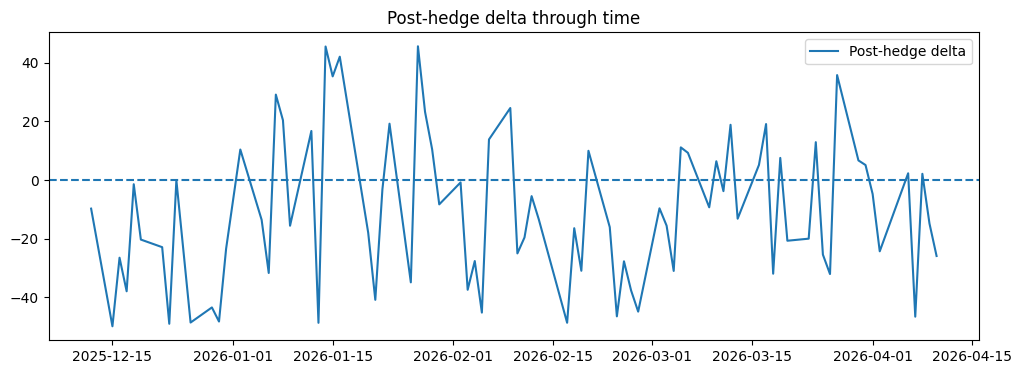

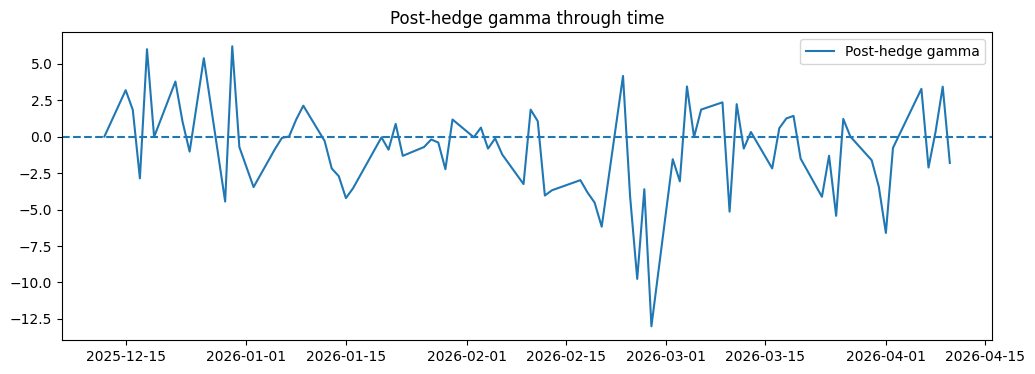

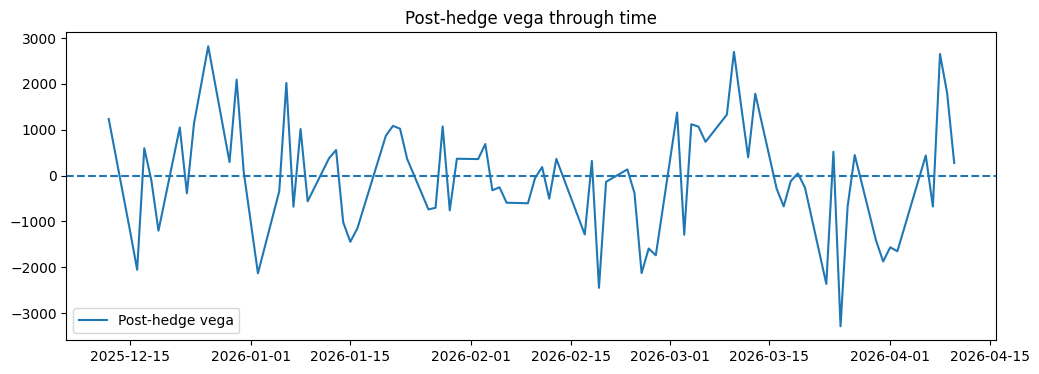

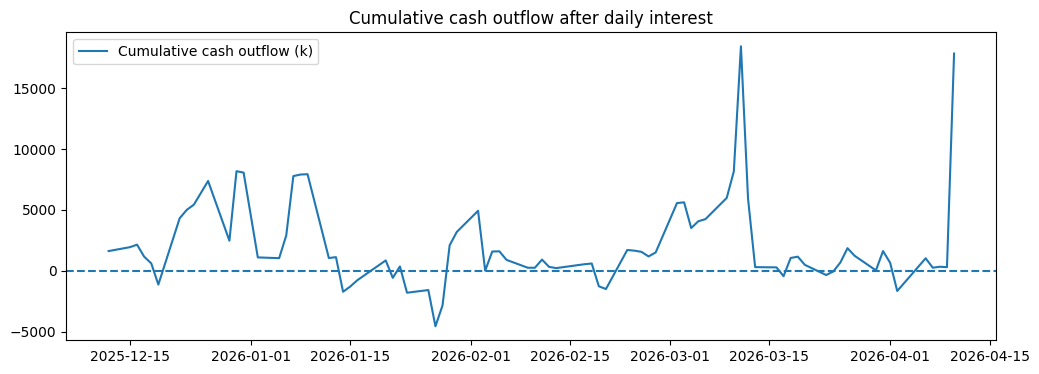

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_delta"], label="Post-hedge delta")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge delta through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_gamma"], label="Post-hedge gamma")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge gamma through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["post_vega"], label="Post-hedge vega")
plt.axhline(0.0, linestyle="--")
plt.title("Post-hedge vega through time")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(history_df["trade_date"], history_df["cumulative_cash_outflow_after_interest_k"], label="Cumulative cash outflow (k)")
plt.axhline(0.0, linestyle="--")
plt.title("Cumulative cash outflow after daily interest")
plt.legend()
plt.show()

## 8. Final position book
This should be flat after the base-expiry liquidation step.


In [26]:
last_day_panel = panel_df.loc[panel_df["trade_date"] == history_df["trade_date"].max()].copy()

final_summary, final_details = portfolio_snapshot(
    day_panel=last_day_panel,
    option_positions=option_positions,
    stock_position=stock_position,
    contract_multiplier=CONTRACT_MULTIPLIER,
)

print("Final summary:")
display(pd.DataFrame([final_summary]))

print("Final option positions:")
display(final_details.sort_values("quantity_contracts", key=lambda s: s.abs(), ascending=False))

Final summary:


,stock_position_shares,option_value,total_delta,total_gamma,total_vega,total_theta
0,74000.0,-2.125011e+06,-25.9362,-1.798452,275.243154,556848.49058


Final option positions:


,contract_id,quantity_contracts,quantity_shares_equiv,price_per_share,delta_per_share,gamma_per_share,vega_per_share,theta_per_share,position_delta,position_gamma,position_vega,position_theta,position_value
0,2026-04-12|210.0|call,-1000.0,-100000.0,28.421345,1.000000,2.779019e-18,1.697868e-16,-7.543815,-100000.000000,-2.779019e-13,-1.697868e-11,754381.451623,-2.842134e+06
7,2026-04-15|215.0|call,115.0,11500.0,23.485803,0.999997,2.413231e-06,3.673717e-04,-7.723747,11499.968091,2.775215e-02,4.224774e+00,-88823.091661,2.700867e+05
1,2026-05-27|205.0|call,57.0,5700.0,34.417981,0.985354,2.145334e-03,3.173521e+00,-9.694114,5616.520324,1.222840e+01,1.808907e+04,-55256.451739,1.961825e+05
2,2026-05-31|210.0|call,39.0,3900.0,29.700102,0.963390,4.476105e-03,7.143669e+00,-12.322591,3757.222081,1.745681e+01,2.786031e+04,-48058.104999,1.158304e+05
8,2026-06-24|220.0|put,-37.0,-3700.0,1.823511,-0.155321,1.106574e-02,2.578389e+01,-11.124319,574.686786,-4.094324e+01,-9.540038e+04,41159.981888,-6.746991e+03
5,2026-06-17|210.0|call,16.0,1600.0,30.310966,0.942343,5.557105e-03,1.187952e+01,-13.420039,1507.748397,8.891368e+00,1.900724e+04,-21472.062081,4.849755e+04
6,2026-06-20|210.0|call,16.0,1600.0,30.423663,0.938855,5.690457e-03,1.271073e+01,-13.550431,1502.168070,9.104731e+00,2.033716e+04,-21680.689731,4.867786e+04
4,2026-06-10|210.0|call,9.0,900.0,30.053019,0.950773,5.185704e-03,9.926467e+00,-13.049581,855.696040,4.667134e+00,8.933820e+03,-11744.622950,2.704772e+04
3,2026-06-03|210.0|call,6.0,600.0,29.803720,0.959553,4.714122e-03,7.972953e+00,-12.568549,575.731558,2.828473e+00,4.783772e+03,-7541.129437,1.788223e+04
9,2026-04-17|235.0|put,-3.0,-300.0,1.113369,-0.281075,5.353295e-02,1.113325e+01,-52.944032,84.322453,-1.605989e+01,-3.339975e+03,15883.209667,-3.340108e+02


In [27]:
# ---------------------------------------------------------
# Hook the DGV solver into the shared comparison framework
# ---------------------------------------------------------

def ensure_theta_portfolio_snapshot():
    current_snapshot = portfolio_snapshot

    if getattr(current_snapshot, "_theta_safe_wrapper", False):
        return

    def portfolio_snapshot_theta_safe(day_panel, option_positions, stock_position=0.0, contract_multiplier=100):
        summary, details = current_snapshot(
            day_panel=day_panel,
            option_positions=option_positions,
            stock_position=stock_position,
            contract_multiplier=contract_multiplier,
        )

        if "total_theta" in summary:
            return summary, details

        df = day_panel.set_index("contract_id")
        total_theta = 0.0

        for cid, qty_contracts in option_positions.items():
            if (cid in df.index) and ("theta" in df.columns):
                total_theta += float(qty_contracts * contract_multiplier * float(df.loc[cid, "theta"]))

        summary = dict(summary)
        summary["total_theta"] = float(total_theta)

        if isinstance(details, pd.DataFrame) and (len(details) > 0):
            details = details.copy()
            if "theta_per_share" not in details.columns:
                theta_map = df["theta"] if "theta" in df.columns else pd.Series(dtype=float)
                details["theta_per_share"] = details["contract_id"].map(theta_map)
            if ("position_theta" not in details.columns) and ("quantity_shares_equiv" in details.columns):
                details["position_theta"] = details["quantity_shares_equiv"] * details["theta_per_share"].fillna(0.0)

        return summary, details

    portfolio_snapshot_theta_safe._theta_safe_wrapper = True
    globals()["portfolio_snapshot"] = portfolio_snapshot_theta_safe


ensure_theta_portfolio_snapshot()


def solve_delta_gamma_vega(
    day_panel,
    base_contract_id,
    base_contracts,
    target_hedge_dte=30,
    max_candidates=20,
    option_search_radius=3,
    contract_multiplier=100,
    stock_round_lot=100,
):
    if "find_best_daily_rebalance" not in globals():
        raise NameError(
            "Run the DGV helper cells above before registering solve_delta_gamma_vega."
        )

    short_dte_range = globals().get(
        "SHORT_HEDGE_DTE_RANGE",
        (max(7, target_hedge_dte // 2), max(14, target_hedge_dte)),
    )
    long_dte_range = globals().get(
        "LONG_HEDGE_DTE_RANGE",
        (max(target_hedge_dte + 15, 45), max(target_hedge_dte + 45, 90)),
    )

    base_book = build_live_base_book(day_panel, base_contract_id, base_contracts)

    rebalance = find_best_daily_rebalance(
        day_panel=day_panel,
        option_positions=base_book,
        stock_position=0.0,
        exclude_contract_ids={base_contract_id},
        max_new_candidates_per_bucket=globals().get(
            "MAX_NEW_CANDIDATES_PER_BUCKET",
            max_candidates,
        ),
        short_dte_range=short_dte_range,
        long_dte_range=long_dte_range,
        option_search_radius=option_search_radius,
        condition_number_limit=globals().get("CONDITION_NUMBER_LIMIT", 5000),
        quantity_penalty=globals().get("QUANTITY_PENALTY", 0.05),
        turnover_penalty=globals().get("TURNOVER_PENALTY", 0.01),
        inventory_penalty_weight=globals().get("INVENTORY_PENALTY_WEIGHT", 0.02),
        max_abs_option_trade=globals().get("MAX_ABS_OPTION_TRADE", 3000),
        max_abs_stock_position=globals().get("MAX_ABS_STOCK_POSITION", 150_000),
        max_gross_option_contracts=globals().get("MAX_GROSS_OPTION_CONTRACTS", 5000),
        contract_multiplier=contract_multiplier,
    )

    if rebalance is None:
        return solve_delta(
            day_panel=day_panel,
            base_contract_id=base_contract_id,
            base_contracts=base_contracts,
            target_hedge_dte=target_hedge_dte,
            max_candidates=max_candidates,
            option_search_radius=option_search_radius,
            contract_multiplier=contract_multiplier,
            stock_round_lot=stock_round_lot,
        )

    target_option_book = clean_position_book(
        rebalance["post_option_positions"],
        day_panel,
    )
    target_stock_position = float(rebalance["post_stock_position"])
    stock_position_theory = float(rebalance["q_stock_theory"])
    stock_position_actual = float(rebalance["post_stock_position"])
    residual_objective = float(rebalance["objective"])

    selected_hedge_id = (
        f"{rebalance['contract_a']} ({rebalance['q_a_actual']:+.0f}) | "
        f"{rebalance['contract_b']} ({rebalance['q_b_actual']:+.0f})"
    )

    return {
        "selected_hedge_id": selected_hedge_id,
        "target_option_book": target_option_book,
        "target_stock_position": target_stock_position,
        "hedge_contracts_theory": np.nan,
        "hedge_contracts_actual": np.nan,
        "stock_position_theory": stock_position_theory,
        "stock_position_actual": stock_position_actual,
        "targeted_greek": "delta_gamma_vega",
        "residual_objective": residual_objective,
    }


STRATEGY_SOLVERS["delta_gamma_vega"] = solve_delta_gamma_vega
strategies_to_compare = STRATEGIES_TO_RUN + ["delta_gamma_vega"]
combined_history_df, combined_trade_log_df = run_multiple_strategies(
    panel_df=panel_df,
    regime_df=regime_df,
    strategies_to_run=strategies_to_compare,
    initial_underlying_shares=INITIAL_UNDERLYING_SHARES,
    base_option_type=BASE_OPTION_TYPE,
    base_position_sign=BASE_POSITION_SIGN,
    target_entry_dte=TARGET_ENTRY_DTE,
    target_hedge_dte=TARGET_HEDGE_DTE,
    contract_multiplier=CONTRACT_MULTIPLIER,
    max_single_candidates=MAX_SINGLE_CANDIDATES,
    option_search_radius=OPTION_SEARCH_RADIUS,
    stock_round_lot=STOCK_ROUND_LOT,
    use_daily_risk_free_rate_for_cash=USE_DAILY_RISK_FREE_RATE_FOR_CASH,
    manual_cash_rate=MANUAL_CASH_RATE,
)

summary_df = summarise_results(combined_history_df)
display(summary_df)


,sample_view,strategy,regime,n_regime_days,n_eligible_days,n_executed_days,hedge_coverage_pct,mean_abs_pre_delta,mean_abs_post_delta,pct_reduction_delta,mean_abs_pre_gamma,mean_abs_post_gamma,pct_reduction_gamma,mean_abs_pre_vega,mean_abs_post_vega,pct_reduction_vega,mean_abs_post_theta,total_option_turnover,total_stock_turnover,final_cash_outflow,avg_daily_cashflow
0,regime,delta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.521637e+06,0.000000e+00
1,regime,delta,low,12,12,11,91.666667,7902.832802,28.303286,99.641859,3039.314555,3039.314555,0.000000,9.338482e+05,9.338482e+05,0.000000,2.318926e+06,0.0,94700.0,2.313810e+07,7.840615e+05
2,regime,delta,medium,55,8,6,75.000000,3612.108207,2.608675,99.927780,353.574905,353.574905,0.000000,2.130207e+05,2.130207e+05,0.000000,3.088127e+05,0.0,198700.0,-1.522288e+06,-1.993579e+05
3,regime,delta_gamma,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.676609e+06,0.000000e+00
4,regime,delta_gamma,low,12,12,11,91.666667,2538.973728,23.233966,99.084907,952.087354,0.092761,99.990257,1.104012e+06,1.089389e+06,1.324511,4.225894e+05,19489.0,316400.0,2.298443e+07,1.640898e+06
5,regime,delta_gamma,medium,55,8,7,87.500000,2929.463976,3.131570,99.893101,88.720379,0.024026,99.972919,7.072904e+04,4.443977e+04,37.168984,4.166176e+04,9703.0,179000.0,-1.677326e+06,-3.886549e+05
6,regime,delta_gamma_vega,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.686589e+06,0.000000e+00
7,regime,delta_gamma_vega,low,12,12,11,91.666667,1659.453671,18.477580,98.886526,718.649838,1.777073,99.752721,1.497729e+05,5.880526e+02,99.607371,4.522686e+05,11628.0,212700.0,2.297453e+07,1.735667e+06
8,regime,delta_gamma_vega,medium,55,8,6,75.000000,2983.734072,1.549572,99.948066,111.811368,0.219898,99.803332,5.603560e+04,1.682044e+02,99.699826,3.285728e+04,6980.0,143500.0,-1.687311e+06,-4.096158e+05
9,regime,delta_theta,high,14,0,0,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.0,0.0,-1.710350e+06,0.000000e+00


## 14. Save outputs

The notebook now exports both the original strategy-level tables and the new
coverage-aware reporting tables used for presentation.


In [ ]:
combined_history_df.to_csv("unified_greek_strategy_history.csv", index=False)
combined_trade_log_df.to_csv("unified_greek_strategy_trade_log.csv", index=False)
coverage_df.to_csv("unified_greek_strategy_coverage.csv", index=False)
regime_summary_df.to_csv("unified_greek_strategy_summary_regime_days.csv", index=False)
executed_summary_df.to_csv("unified_greek_strategy_summary_executed_days.csv", index=False)
validation_df.to_csv("unified_greek_strategy_validation_table.csv", index=False)
bootstrap_ci_df.to_csv("unified_greek_strategy_bootstrap_ci.csv", index=False)

delta_daily_table.to_csv("delta_daily_table.csv", index=False)
delta_gamma_daily_table.to_csv("delta_gamma_daily_table.csv", index=False)
delta_vega_daily_table.to_csv("delta_vega_daily_table.csv", index=False)
delta_theta_daily_table.to_csv("delta_theta_daily_table.csv", index=False)

if "combined_all_df" in globals():
    combined_all_df.to_csv("unified_greek_strategy_history_with_dgv.csv", index=False)
    unified_coverage_df.to_csv("unified_greek_strategy_coverage_with_dgv.csv", index=False)
    unified_regime_summary_df.to_csv("unified_greek_strategy_summary_regime_days_with_dgv.csv", index=False)
    unified_executed_summary_df.to_csv("unified_greek_strategy_summary_executed_days_with_dgv.csv", index=False)

print("Saved CSV outputs to the current directory.")
